# Redundans

patient 1:  p1 ↑   p2 ↑\
patient 2:  p1 ↓   p2 ↓\
patient 3:  p1 ↑   p2 ↑

Identify which proteins are co-regulated

Take your top-50 to top-100 proteins from univariate MI
Compute I(Xi; Xj) for all pairs — this gives protein-protein similarity
This is ~5,000 pairs, computationally feasible

Use hierarchical clustering or community detection on the MI matrix:

Interpretation: Proteins in the same cluster are highly correlated — they likely:

Belong to the same pathway\
Respond to the same upstream regulator\
Reflect the same ARDS mechanism

Test if modules differentiate ARDS

For each module, create an aggregate score (e.g., mean or first PC) and test:

Does the module score differ between ARDS/non-ARDS? (t-test or Mann-Whitney)\
Does it perform better than individual proteins in classification?

Biological validation

Input each module into STRING or Enrichr\
Do the proteins form known pathways? (complement cascade, coagulation, inflammatory cytokines, etc.)\
Do they map to known ARDS mechanisms from literature?

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests

In [2]:

# -------------------------
# Paths
# -------------------------
real_dir = Path("../data/processed")

realdata_path = real_dir / "filtered_data.csv"

ttest_path = Path("../results/ttest/filtered_data/selected_features_k20.csv")
fs_path    = Path("../results/fs/selected_features_n_features20.csv")
mi_path    = Path("../results/mi_uni_test/selected_features_k20.csv")  

# -------------------------
# Load data
# -------------------------
realdata = pd.read_csv(realdata_path)

ttest_df = pd.read_csv(ttest_path)
fs_df    = pd.read_csv(fs_path)
mi_df   = pd.read_csv(mi_path)

# -------------------------
# Helper: find feature column
# -------------------------
def find_feature_col(df):
    for c in ["protein", "Protein", "feature", "Feature", "selected_feature", "features"]:
        if c in df.columns:
            return c
    return df.columns[0]  # fallback

ttest_col = find_feature_col(ttest_df)
fs_col    = find_feature_col(fs_df)
mi_col    = find_feature_col(mi_df)
# -------------------------
# Extract proteins
# -------------------------
features_ttest_real = set(ttest_df[ttest_col])
features_mi_real = set(mi_df[mi_col])
features_fs_real    = set(fs_df[fs_col])

print(len(features_ttest_real), len(features_mi_real), len(features_fs_real))
shared_fs_mi = features_fs_real & features_mi_real
print("FS and MI share at least one protein" if shared_fs_mi else "FS and MI share no proteins")
# -------------------------
# Union of proteins
# -------------------------
all_features = sorted(features_ttest_real | features_fs_real | features_mi_real)

print("Number of proteins:", len(all_features))
print(all_features[:10])

20 20 20
FS and MI share at least one protein
Number of proteins: 59
['seq.10428.1', 'seq.11270.17', 'seq.11439.88', 'seq.12351.25', 'seq.12832.10', 'seq.13937.75', 'seq.14245.195', 'seq.14705.1', 'seq.17456.53', 'seq.17725.37']


/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_67734/1593771975.py:15: DtypeWarning: Columns (10818,10820) have mixed types. Specify dtype option on import or set low_memory=False.
  realdata = pd.read_csv(realdata_path)


In [3]:
method_map = {}

for p in features_ttest_real:
    method_map.setdefault(p, []).append("ttest")

for p in features_mi_real:
    method_map.setdefault(p, []).append("MI")

for p in features_fs_real:
    method_map.setdefault(p, []).append("FS")

method_df = pd.DataFrame({
    "protein": list(method_map.keys()),
    "method": [",".join(method_map[p]) for p in method_map]
})

X = realdata[method_df["protein"]]
X_ards = realdata.loc[realdata["ards"] == 1, method_df["protein"]]
X_non_ards = realdata.loc[realdata["ards"] == 0, method_df["protein"]]

# Hierarktiskt kluster

In [12]:
color_map = {
    "ttest": "#1f77b4",
    "MI": "#d62728",
    "FS": "#2ca02c",
    "ttest,MI": "#9467bd",
    "ttest,FS": "#8c564b",
    "MI,FS": "#e377c2",
    "ttest,MI,FS": "#7f7f7f"
}


from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import entropy
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score


def entropy_discrete(x):
    """Shannon entropy for a discrete vector."""
    counts = np.bincount(x)
    probs = counts[counts > 0] / len(x)
    return entropy(probs, base=2)


def mutual_info_discrete(x, y):
    """Mutual information for two discrete vectors."""
    return mutual_info_score(x, y)


def build_vi_distance_matrix(X_df, n_bins=5, strategy="quantile"):
    """
    Build a variation-of-information distance matrix for columns in X_df.

    Parameters
    ----------
    X_df : pd.DataFrame
        Rows = samples, columns = proteins
    n_bins : int
        Number of bins for discretization
    strategy : str
        Passed to KBinsDiscretizer ('uniform', 'quantile', 'kmeans')

    Returns
    -------
    dist_df : pd.DataFrame
        Symmetric distance matrix
    """
    proteins = X_df.columns

    # Discretize each protein column
    disc = KBinsDiscretizer(
        n_bins=n_bins,
        encode="ordinal",
        strategy=strategy
    )
    X_disc = disc.fit_transform(X_df).astype(int)

    p = X_disc.shape[1]
    dist = np.zeros((p, p))

    # Precompute entropies
    H = np.zeros(p)
    for i in range(p):
        H[i] = entropy_discrete(X_disc[:, i])

    # Compute VI distance
    for i in range(p):
        for j in range(i + 1, p):
            I_ij = mutual_info_discrete(X_disc[:, i], X_disc[:, j])
            d_ij = H[i] + H[j] - 2 * I_ij
            dist[i, j] = d_ij
            dist[j, i] = d_ij

    np.fill_diagonal(dist, 0)

    dist_df = pd.DataFrame(dist, index=proteins, columns=proteins)
    return dist_df


def build_cluster_df_mi(X_df, method_map, n_clusters=6, n_bins=5, strategy="quantile"):
    dist_df = build_vi_distance_matrix(X_df, n_bins=n_bins, strategy=strategy)

    Z = linkage(squareform(dist_df.values), method="average")

    cluster_df_local = pd.DataFrame({
        "protein": X_df.columns,
        "cluster": fcluster(Z, t=n_clusters, criterion="maxclust"),
        "method": [",".join(method_map[p]) for p in X_df.columns]
    }).sort_values(["cluster", "protein"]).reset_index(drop=True)

    return dist_df, Z, cluster_df_local

def build_cluster_df(X_df, method_map, n_clusters=6):
    corr = X_df.corr()
    dist = 1 - np.abs(corr)
    np.fill_diagonal(dist.values, 0)
    Z = linkage(squareform(dist), method="average")

    cluster_df_local = pd.DataFrame({
        "protein": corr.index,
        "cluster": fcluster(Z, t=n_clusters, criterion="maxclust"),
        "method": [",".join(method_map[p]) for p in corr.index]
    }).sort_values(["cluster", "protein"]).reset_index(drop=True)

    return corr, Z, cluster_df_local

def visualize_clustering(corr, Z, cluster_df_local, method_df, title, color_map):
    row_colors = (
        method_df
        .set_index("protein")
        .loc[corr.index, "method"]
        .map(color_map)
        .fillna("#9e9e9e")
    )

    sns.clustermap(
        corr,
        row_linkage=Z,
        col_linkage=Z,
        cmap="coolwarm",
        center=0,
        figsize=(12, 12),
        row_colors=row_colors,
        col_colors=row_colors
    )
    plt.suptitle(title, y=1.02)
    plt.show()

    print(f"{title} - method counts per cluster:")
    print(cluster_df_local.groupby("cluster")["method"].value_counts())
    print()

/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavio

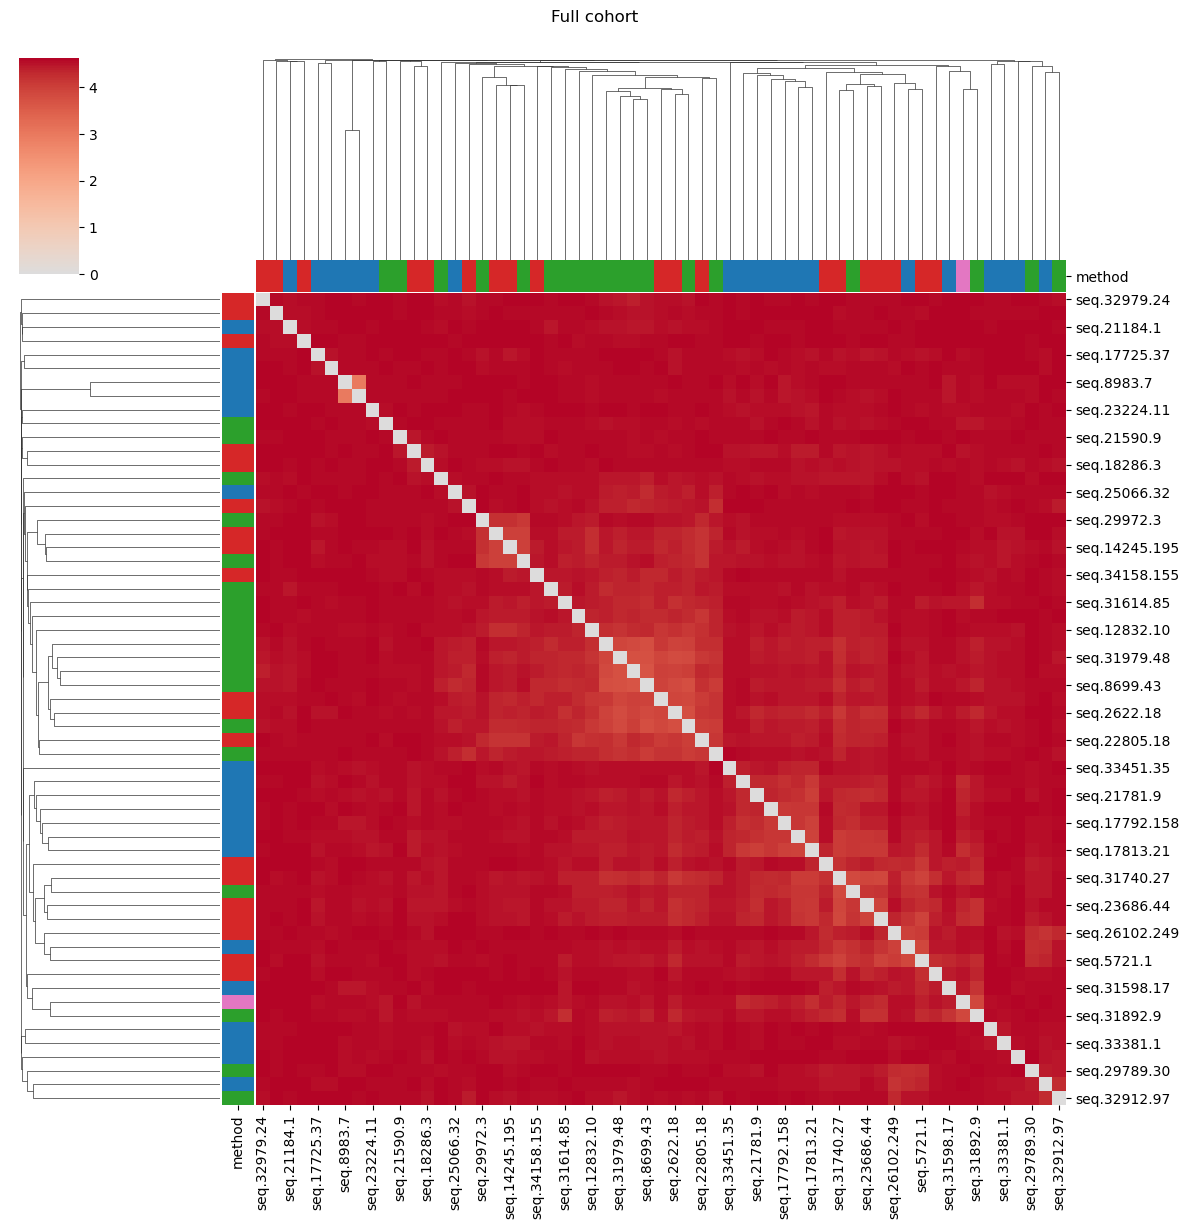

Full cohort - method counts per cluster:
cluster  method
1        MI         3
         ttest      1
2        ttest      2
3        ttest      2
4        FS         1
         ttest      1
5        MI         2
         FS         1
6        FS        17
         MI        14
         ttest     14
         MI,FS      1
Name: count, dtype: int64



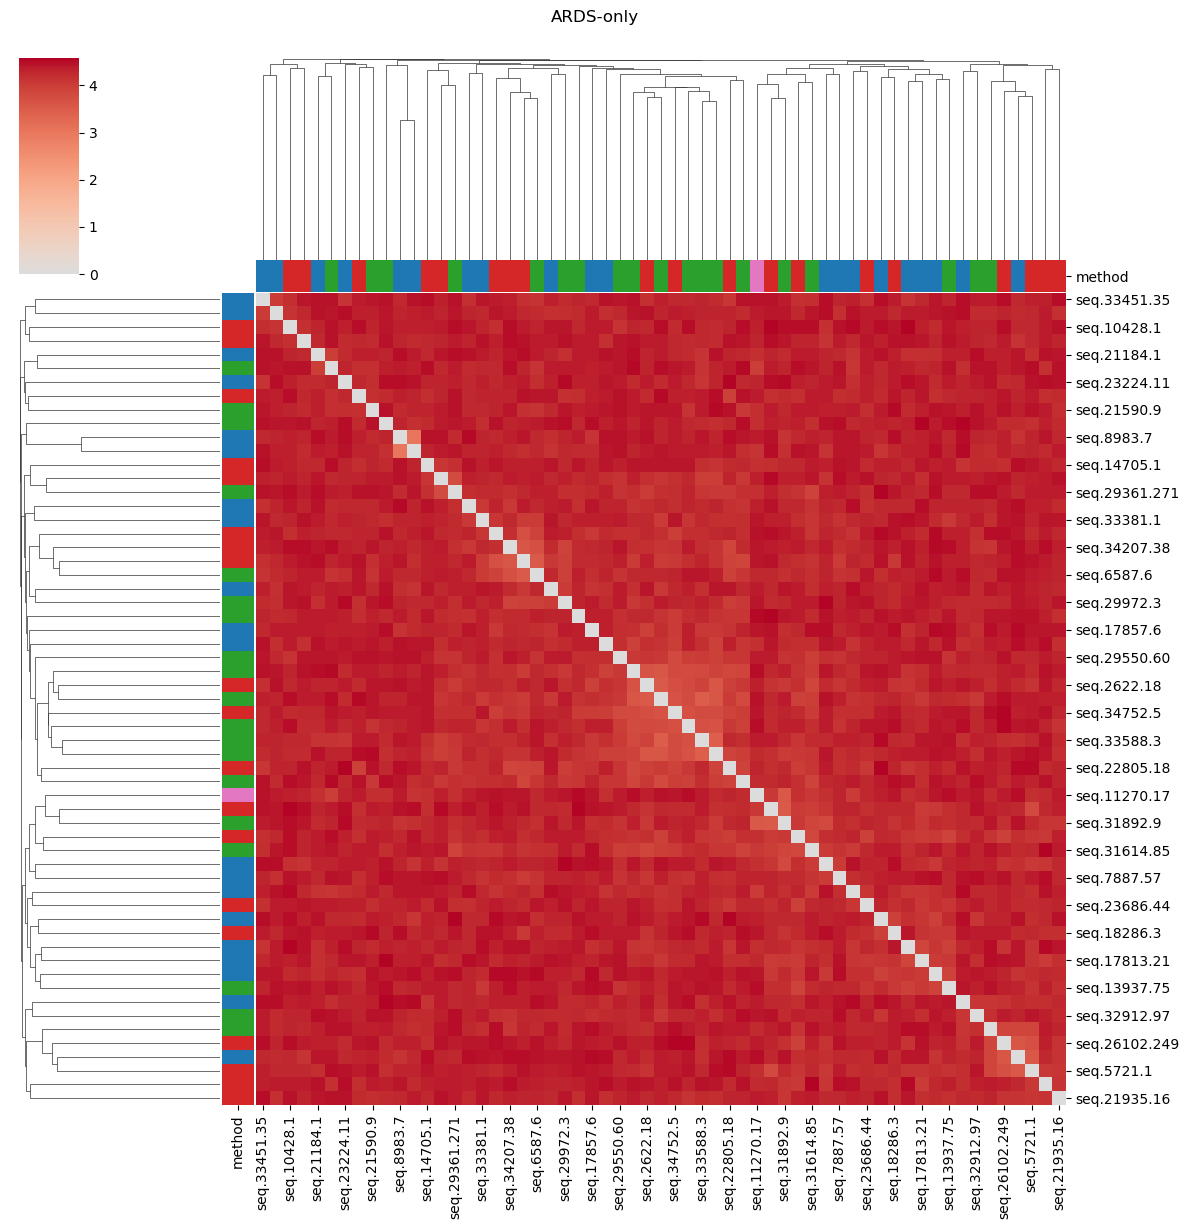

ARDS-only - method counts per cluster:
cluster  method
1        MI         2
         ttest      2
2        FS         2
         ttest      2
         MI         1
3        ttest      2
         FS         1
4        FS        11
         MI         8
         ttest      5
5        ttest      7
         MI         4
         FS         3
         MI,FS      1
6        MI         4
         FS         2
         ttest      2
Name: count, dtype: int64



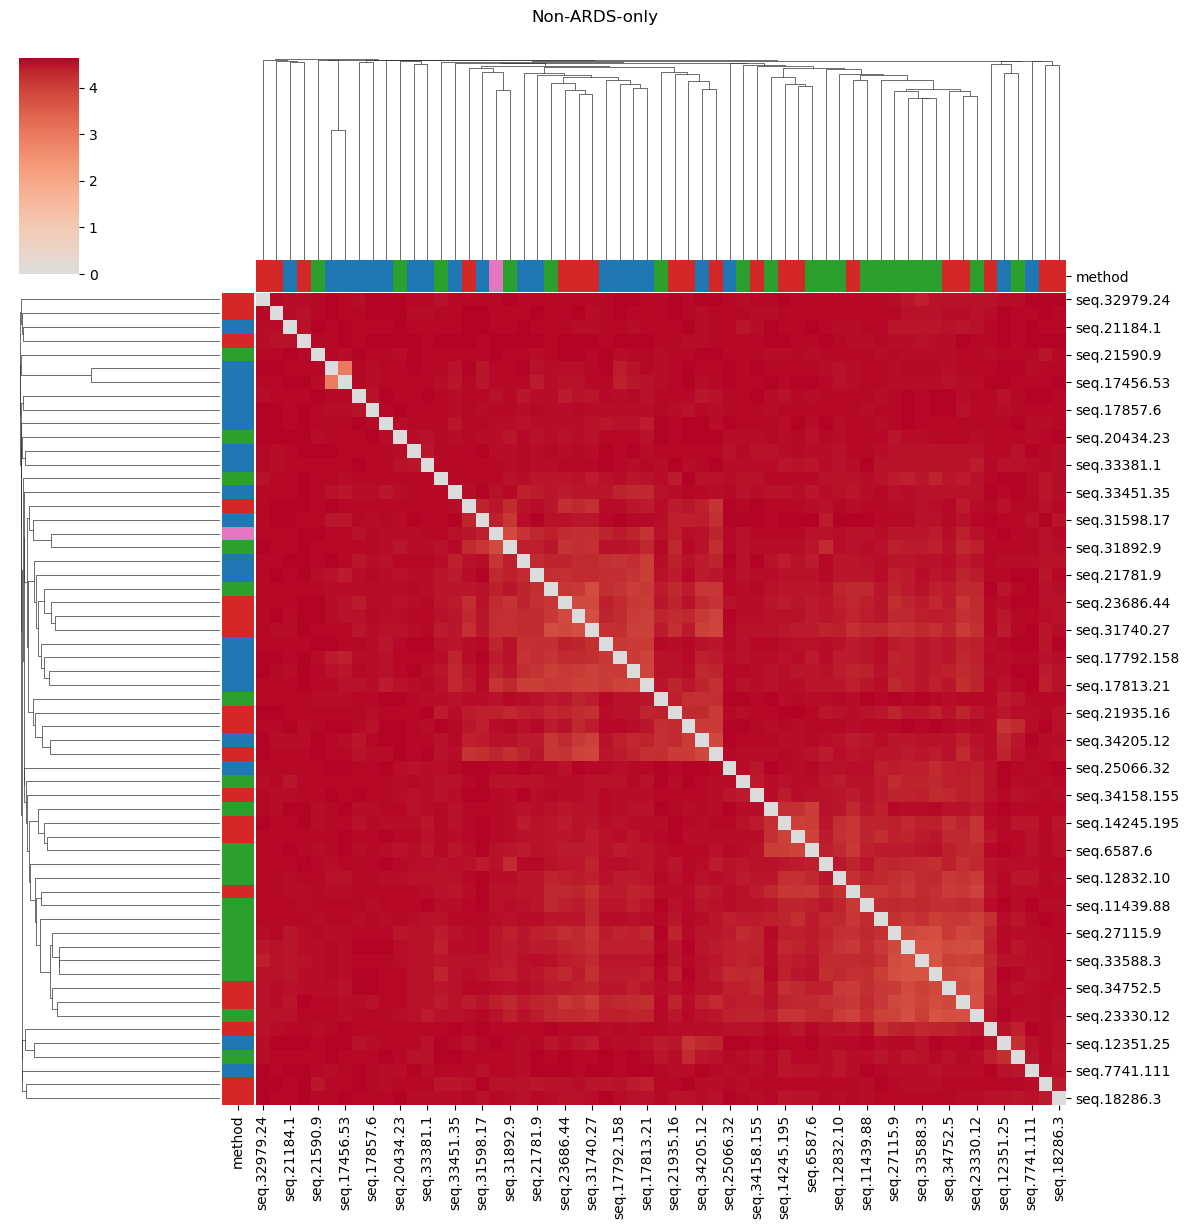

Non-ARDS-only - method counts per cluster:
cluster  method
1        MI         3
         ttest      1
2        ttest      2
         FS         1
3        ttest      2
4        ttest      2
         FS         1
5        FS        17
         MI        16
         ttest     12
         MI,FS      1
6        ttest      1
Name: count, dtype: int64



In [13]:
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns
)
X_scaled_ards = pd.DataFrame(
    StandardScaler().fit_transform(X_ards),
    columns=X_ards.columns
)
X_scaled_non_ards = pd.DataFrame(
    StandardScaler().fit_transform(X_non_ards),
    columns=X_non_ards.columns
)

# Apply same clustering logic to all three datasets
corr, Z, cluster_df = build_cluster_df_mi(X_scaled, method_map, n_clusters=6)
corr_ards, Z_ards, cluster_df_ards = build_cluster_df_mi(X_scaled_ards, method_map, n_clusters=6)
corr_non_ards, Z_non_ards, cluster_df_non_ards = build_cluster_df_mi(X_scaled_non_ards, method_map, n_clusters=6)

visualize_clustering(corr, Z, cluster_df, method_df, "Full cohort", color_map)
visualize_clustering(corr_ards, Z_ards, cluster_df_ards, method_df, "ARDS-only", color_map)
visualize_clustering(corr_non_ards, Z_non_ards, cluster_df_non_ards, method_df, "Non-ARDS-only", color_map)

In [14]:
def build_pairs_df(corr_df, cluster_df_local, method_map, ascending=False):
    cluster_lookup = cluster_df_local.set_index("protein")["cluster"]
    pairs = []

    proteins = list(corr_df.columns)
    for i, p1 in enumerate(proteins):
        for j, p2 in enumerate(proteins):
            if j <= i:
                continue

            pairs.append({
                "protein1": p1,
                "protein2": p2,
                "corr": corr_df.loc[p1, p2],
                "abs_corr": abs(corr_df.loc[p1, p2]),
                "cluster1": cluster_lookup.loc[p1],
                "cluster2": cluster_lookup.loc[p2],
                "method1": ",".join(method_map[p1]),
                "method2": ",".join(method_map[p2])
            })

    pairs_df_local = pd.DataFrame(pairs).sort_values(
        "abs_corr",
        ascending=ascending
    ).reset_index(drop=True)

    return pairs_df_local

# Full cohort (kept as pairs_df for downstream compatibility)
pairs_df = build_pairs_df(corr, cluster_df, method_map, ascending=False)
print("Full cohort - top 10 by abs_corr (descending):")
print(pairs_df.head(10))

# ARDS-only
pairs_df_ards = build_pairs_df(corr_ards, cluster_df_ards, method_map, ascending=False)
print("\nARDS-only - top 10 by abs_corr (descending):")
print(pairs_df_ards.head(10))

# Non-ARDS-only
pairs_df_non_ards = build_pairs_df(corr_non_ards, cluster_df_non_ards, method_map, ascending=False)
print("\nNon-ARDS-only - top 10 by abs_corr (descending):")
print(pairs_df_non_ards.head(10))

Full cohort - top 10 by abs_corr (descending):
       protein1      protein2      corr  abs_corr  cluster1  cluster2 method1  \
0  seq.23224.11  seq.29789.30  4.631127  4.631127         4         6   ttest   
1  seq.12351.25   seq.10428.1  4.630373  4.630373         6         1   ttest   
2  seq.17725.37   seq.33381.1  4.629046  4.629046         2         6   ttest   
3   seq.21781.9  seq.7741.111  4.627529  4.627529         6         6   ttest   
4  seq.12351.25   seq.8327.26  4.626856  4.626856         6         6   ttest   
5   seq.10428.1  seq.31614.85  4.626481  4.626481         1         6      MI   
6   seq.17857.6  seq.32979.24  4.626332  4.626332         2         1   ttest   
7   seq.18286.3   seq.10428.1  4.625526  4.625526         5         1      MI   
8  seq.26103.20   seq.10428.1  4.623636  4.623636         6         1   ttest   
9  seq.23224.11   seq.14705.1  4.623391  4.623391         4         1   ttest   

  method2  
0      FS  
1      MI  
2   ttest  
3   ttest  
4

In [15]:
# Difference in correlation (ARDS - Non-ARDS)

# -----------------------------
# Permutation test for difference in correlation
# -----------------------------
def permutation_test_corr_diff(X, y, p1, p2, n_perm=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    y = np.asarray(y)

    # Original groups
    mask_ards = (y == 1)
    mask_non = (y == 0)

    x1_ards = X.loc[mask_ards, p1]
    x2_ards = X.loc[mask_ards, p2]
    x1_non = X.loc[mask_non, p1]
    x2_non = X.loc[mask_non, p2]

    corr_ards = np.corrcoef(x1_ards, x2_ards)[0, 1]
    corr_non = np.corrcoef(x1_non, x2_non)[0, 1]

    # If one of the correlations is undefined, return NaN
    if np.isnan(corr_ards) or np.isnan(corr_non):
        return np.nan, np.nan, corr_ards, corr_non

    observed_diff = corr_ards - corr_non

    # Permutation null distribution
    perm_diffs = np.empty(n_perm)

    for b in range(n_perm):
        y_perm = rng.permutation(y)

        mask_ards_p = (y_perm == 1)
        mask_non_p = (y_perm == 0)

        c1 = np.corrcoef(X.loc[mask_ards_p, p1], X.loc[mask_ards_p, p2])[0, 1]
        c0 = np.corrcoef(X.loc[mask_non_p, p1], X.loc[mask_non_p, p2])[0, 1]

        # If a permuted correlation is undefined, set to 0 difference
        if np.isnan(c1) or np.isnan(c0):
            perm_diffs[b] = 0.0
        else:
            perm_diffs[b] = c1 - c0

    # Two-sided permutation p-value with +1 correction
    p_value = (np.sum(np.abs(perm_diffs) >= np.abs(observed_diff)) + 1) / (n_perm + 1)

    return observed_diff, p_value, corr_ards, corr_non


# -----------------------------
# Compare all pairs with permutation test + FDR correction
# -----------------------------
def compare_pairs_with_permutation(
    pairs_df_ards,
    pairs_df_non_ards,
    X,
    y,
    n_perm=500,
    alpha=0.05,
    random_state=42
):
    merged = pairs_df_ards.merge(
        pairs_df_non_ards,
        on=["protein1", "protein2"],
        suffixes=("_ards", "_non_ards")
    )

    results = []

    for idx, row in merged.iterrows():
        p1 = row["protein1"]
        p2 = row["protein2"]

        diff, pval, corr_ards, corr_non = permutation_test_corr_diff(
            X=X,
            y=y,
            p1=p1,
            p2=p2,
            n_perm=n_perm,
            random_state=random_state + idx
        )

        results.append({
            **row.to_dict(),
            "corr_ards_recomputed": corr_ards,
            "corr_non_ards_recomputed": corr_non,
            "corr_diff": diff,
            "abs_corr_diff": np.abs(diff) if pd.notna(diff) else np.nan,
            "p_value": pval
        })

    result_df = pd.DataFrame(results)

    # Multiple testing correction (FDR / Benjamini-Hochberg)
    valid_mask = result_df["p_value"].notna()

    p_adj = np.full(len(result_df), np.nan)
    reject = np.full(len(result_df), False)

    if valid_mask.sum() > 0:
        reject_valid, p_adj_valid, _, _ = multipletests(
            result_df.loc[valid_mask, "p_value"],
            alpha=alpha,
            method="fdr_bh"
        )
        p_adj[valid_mask] = p_adj_valid
        reject[valid_mask] = reject_valid

    result_df["p_adj"] = p_adj
    result_df["significant_raw"] = result_df["p_value"] < alpha
    result_df["significant_fdr"] = reject

    return result_df.sort_values(
        ["significant_fdr", "abs_corr_diff"],
        ascending=[False, False]
    ).reset_index(drop=True)


# -----------------------------
# Run
# -----------------------------
pairs_diff_df = compare_pairs_with_permutation(
    pairs_df_ards,
    pairs_df_non_ards,
    X_scaled,  # original X or X_scaled
    realdata["ards"].values,
    n_perm=500,
    alpha=0.05,
    random_state=42
)

print(pairs_diff_df.head(10))

        protein1      protein2  corr_ards  abs_corr_ards  cluster1_ards  \
0    seq.34752.5  seq.29550.60   3.825214       3.825214              4   
1   seq.31979.48  seq.23330.12   3.609257       3.609257              4   
2   seq.29550.60  seq.31614.85   3.979734       3.979734              4   
3   seq.25066.32   seq.8699.43   3.942724       3.942724              4   
4    seq.29972.3  seq.31979.48   4.368725       4.368725              4   
5    seq.27115.9  seq.23330.12   3.767637       3.767637              4   
6   seq.17768.50  seq.23330.12   4.458295       4.458295              5   
7  seq.17792.158  seq.28386.42   4.299515       4.299515              5   
8   seq.26103.20  seq.23224.11   4.504465       4.504465              1   
9  seq.34158.155  seq.31614.85   4.087534       4.087534              4   

   cluster2_ards method1_ards method2_ards  corr_non_ards  abs_corr_non_ards  \
0              4           MI           FS       4.403836           4.403836   
1             

## Graph networks

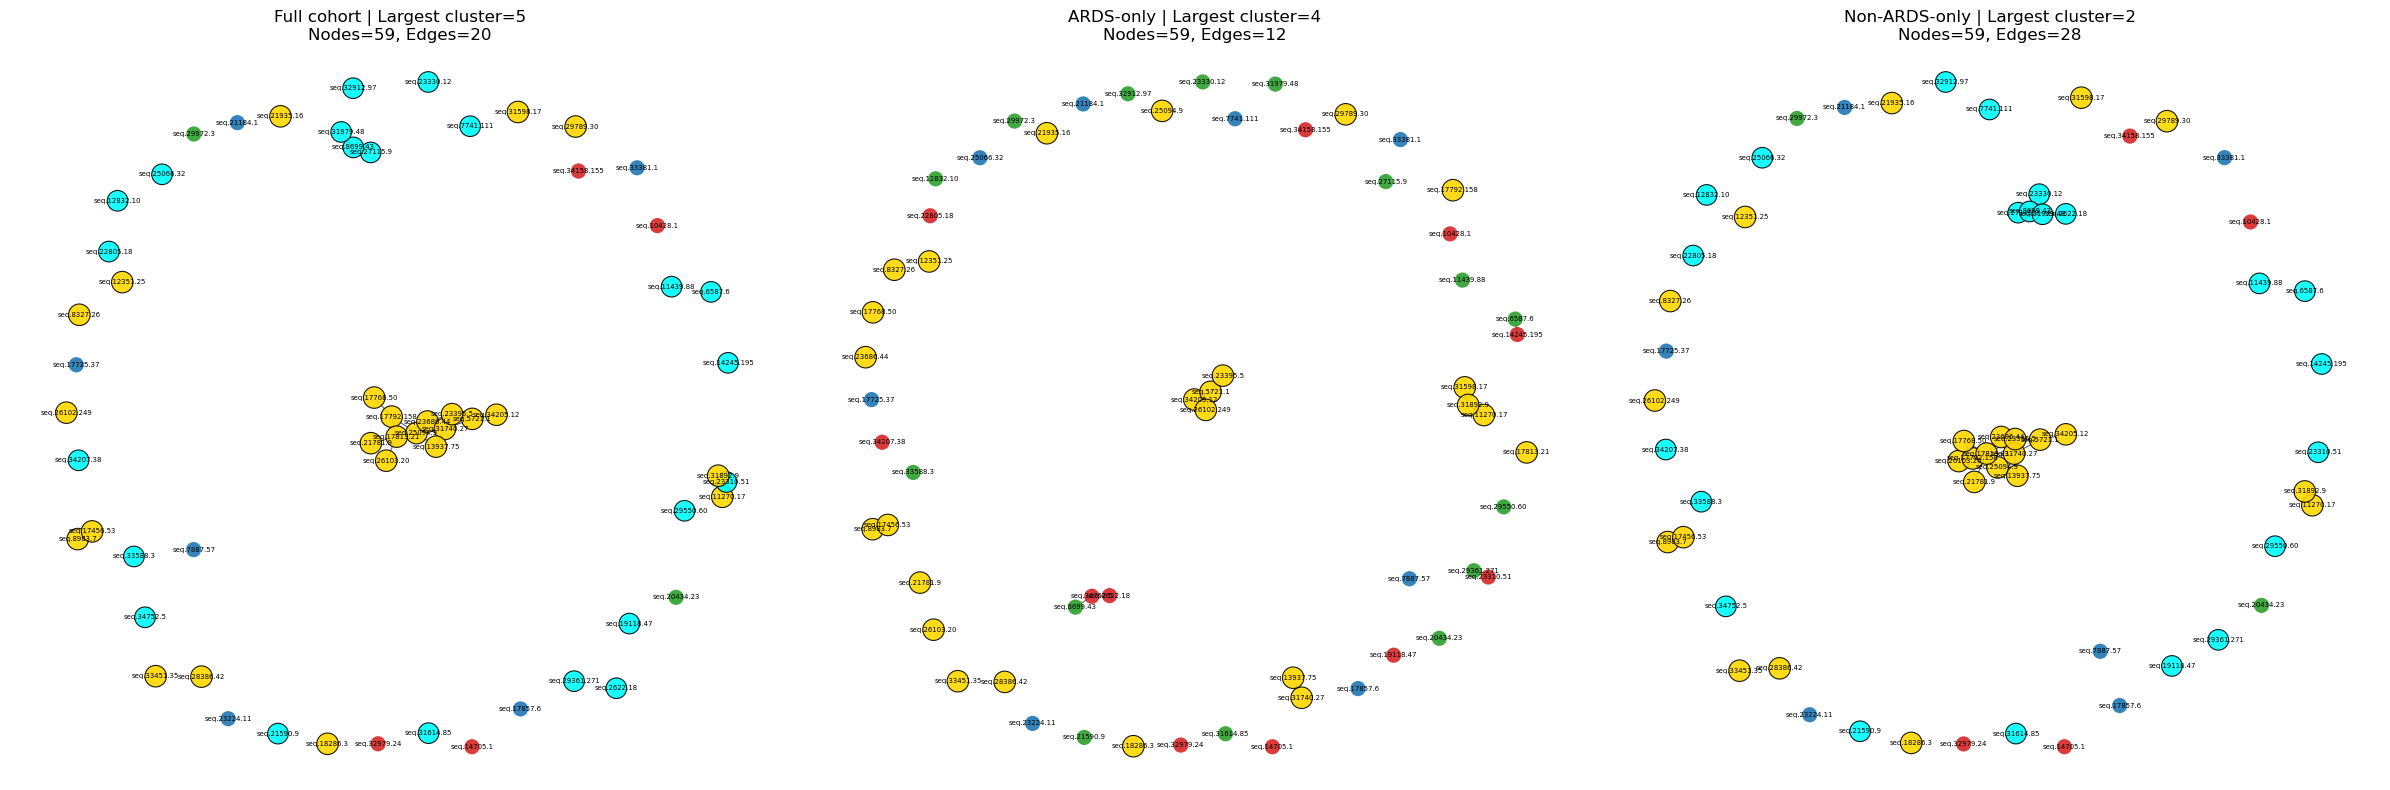

Highlight legend:
- gold: protein is in the largest cluster of all three datasets
- cyan: protein is in the largest cluster of exactly two datasets


In [12]:
import networkx as nx

def build_graph_from_corr(corr_df, cluster_df_local, method_map, threshold=0.7):
    cluster_lookup = cluster_df_local.set_index("protein")["cluster"]
    G_local = nx.Graph()

    for p in corr_df.columns:
        method_str = ",".join(method_map[p])
        cluster_id = cluster_lookup.loc[p]
        G_local.add_node(p, method=method_str, cluster=cluster_id)

    proteins = list(corr_df.columns)
    for i, p1 in enumerate(proteins):
        for j, p2 in enumerate(proteins):
            if j <= i:
                continue
            r = corr_df.loc[p1, p2]
            if abs(r) > threshold:
                G_local.add_edge(p1, p2, weight=r, abs_weight=abs(r))

    return G_local

def get_largest_cluster_proteins(cluster_df_local):
    cluster_counts = cluster_df_local["cluster"].value_counts()
    largest_cluster = cluster_counts.index[0]
    return set(cluster_df_local.loc[cluster_df_local["cluster"] == largest_cluster, "protein"]), largest_cluster

def plot_graph_networks_1x3(corr_triplet, cluster_df_triplet, method_map, color_map, threshold=0.7):
    titles = ["Full cohort", "ARDS-only", "Non-ARDS-only"]
    graphs = {}

    largest_sets = []
    largest_ids = []
    for cluster_df_local in cluster_df_triplet:
        proteins_set, cluster_id = get_largest_cluster_proteins(cluster_df_local)
        largest_sets.append(proteins_set)
        largest_ids.append(cluster_id)

    shared_all_three = largest_sets[0] & largest_sets[1] & largest_sets[2]
    shared_any_two = (
        (largest_sets[0] & largest_sets[1])
        | (largest_sets[0] & largest_sets[2])
        | (largest_sets[1] & largest_sets[2])
    ) - shared_all_three

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    for i, (ax, title, corr_df, cluster_df_local) in enumerate(zip(axes, titles, corr_triplet, cluster_df_triplet)):
        G_local = build_graph_from_corr(
            corr_df,
            cluster_df_local,
            method_map,
            threshold=threshold
        )
        graphs[title] = G_local

        largest_cluster_nodes = largest_sets[i]

        base_colors = {n: color_map.get(",".join(method_map[n]), "grey") for n in G_local.nodes()}
        node_colors = []
        node_sizes = []
        node_edgecolors = []
        node_linewidths = []

        for n in G_local.nodes():
            if n in largest_cluster_nodes and n in shared_all_three:
                node_colors.append("gold")
                node_sizes.append(240)
                node_edgecolors.append("black")
                node_linewidths.append(0.8)
            elif n in largest_cluster_nodes and n in shared_any_two:
                node_colors.append("cyan")
                node_sizes.append(220)
                node_edgecolors.append("black")
                node_linewidths.append(0.8)
            else:
                node_colors.append(base_colors[n])
                node_sizes.append(120)
                node_edgecolors.append("none")
                node_linewidths.append(0.0)

        pos = nx.spring_layout(G_local, seed=1)

        nx.draw_networkx_nodes(
            G_local,
            pos,
            node_color=node_colors,
            node_size=node_sizes,
            edgecolors=node_edgecolors,
            linewidths=node_linewidths,
            alpha=0.9,
            ax=ax
        )
        nx.draw_networkx_edges(
            G_local,
            pos,
            alpha=0.6,
            width=0.8,
            ax=ax
        )
        nx.draw_networkx_labels(
            G_local,
            pos,
            font_size=5,
            ax=ax
        )

        ax.set_title(
            f"{title} | Largest cluster={largest_ids[i]}\n"
            f"Nodes={G_local.number_of_nodes()}, Edges={G_local.number_of_edges()}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("Highlight legend:")
    print("- gold: protein is in the largest cluster of all three datasets")
    print("- cyan: protein is in the largest cluster of exactly two datasets")

    return graphs

# Build and plot all three graph networks
graph_threshold = 0.7
graph_dict = plot_graph_networks_1x3(
    [corr, corr_ards, corr_non_ards],
    [cluster_df, cluster_df_ards, cluster_df_non_ards],
    method_map,
    color_map,
    threshold=graph_threshold
)

# Keep backward compatibility with downstream cells
G = graph_dict["Full cohort"]
G_ards = graph_dict["ARDS-only"]
G_non_ards = graph_dict["Non-ARDS-only"]

In [ ]:
degree_dict = dict(G.degree())

strength_dict = {
    node: sum(abs(data["weight"]) for _, _, data in G.edges(node, data=True))
    for node in G.nodes()
}

hub_df = pd.DataFrame({
    "protein": list(G.nodes()),
    "degree": [degree_dict[n] for n in G.nodes()],
    "strength": [strength_dict[n] for n in G.nodes()],
    "method": [G.nodes[n]["method"] for n in G.nodes()],
    "cluster": [G.nodes[n]["cluster"] for n in G.nodes()]
})

hub_df = hub_df.sort_values(
    ["degree", "strength"],
    ascending=[False, False]
)

print(hub_df.head(20))

          protein  degree  strength method  cluster
2    seq.17813.21       5  3.780956  ttest        5
21   seq.31740.27       5  3.700919     MI        5
16    seq.25094.9       4  2.926950  ttest        5
35    seq.23395.5       3  2.286366     MI        5
26     seq.5721.1       3  2.233102     MI        5
7   seq.17792.158       3  2.232683  ttest        5
33   seq.23686.44       3  2.208396     MI        5
55   seq.13937.75       2  1.550319     FS        5
53    seq.8699.43       2  1.426664     FS        5
8      seq.8983.7       1  0.907296  ttest        5
9    seq.17456.53       1  0.907296  ttest        5
17   seq.26103.20       1  0.764040  ttest        5
0    seq.34205.12       1  0.763929  ttest        5
10    seq.21781.9       1  0.742060  ttest        5
29   seq.11270.17       1  0.731388  MI,FS        5
40    seq.31892.9       1  0.731388     FS        5
1    seq.17768.50       1  0.724959  ttest        5
50    seq.27115.9       1  0.715033     FS        5
51   seq.319

# Gå vidare 

1️⃣ Identifiera kluster 5
2️⃣ Beräkna PCA module score
3️⃣ Testa association med ARDS
4️⃣ Expandera klustret i hela datasetet
5️⃣ Gör pathway enrichment
6️⃣ Testa robusthet via bootstrap

# Kluster 5

In [ ]:
cluster5 = cluster_df[cluster_df["cluster"] == 5]
hub_5 = hub_df[hub_df["cluster"] == 5].sort_values(["degree", "strength"], ascending=[False, False])
print(cluster5.head(5))
print("----------")
print(hub_5.head(5))

         protein  cluster method
39   seq.10428.1        5     MI
29  seq.11270.17        5  MI,FS
41  seq.11439.88        5     FS
15  seq.12351.25        5  ttest
42  seq.12832.10        5     FS
----------
         protein  degree  strength method  cluster
2   seq.17813.21       5  3.780956  ttest        5
21  seq.31740.27       5  3.700919     MI        5
16   seq.25094.9       4  2.926950  ttest        5
35   seq.23395.5       3  2.286366     MI        5
26    seq.5721.1       3  2.233102     MI        5


In [ ]:
# Check correlation and mutual information within cluster 5
from itertools import combinations
from sklearn.feature_selection import mutual_info_regression

cluster5_proteins = cluster5["protein"].tolist()
cluster5_pairs = []

for p1, p2 in combinations(cluster5_proteins, 2):
    pair_corr = corr.loc[p1, p2]
    pair_mi = mutual_info_regression(
        X_scaled[[p1]],
        X_scaled[p2],
        random_state=42
    )[0]

    cluster5_pairs.append({
        "protein1": p1,
        "protein2": p2,
        "corr": pair_corr,
        "abs_corr": abs(pair_corr),
        "mutual_information": pair_mi
    })

cluster5_pairs_df = pd.DataFrame(cluster5_pairs).sort_values(
    ["mutual_information", "abs_corr"],
    ascending=[False, False]
).reset_index(drop=True)

cluster5_pairs_df

,protein1,protein2,corr,abs_corr,mutual_information
0,seq.17456.53,seq.8983.7,0.907296,0.907296,1.279791
1,seq.33588.3,seq.8699.43,0.431102,0.431102,0.614894
2,seq.31979.48,seq.33588.3,0.434396,0.434396,0.580095
3,seq.13937.75,seq.31740.27,0.799205,0.799205,0.580075
4,seq.31979.48,seq.8699.43,0.711632,0.711632,0.563146
...,...,...,...,...,...
1220,seq.14705.1,seq.33451.35,0.003230,0.003230,0.000000
1221,seq.23310.51,seq.26103.20,-0.002880,0.002880,0.000000
1222,seq.17813.21,seq.25066.32,-0.002428,0.002428,0.000000
1223,seq.21590.9,seq.29550.60,0.001100,0.001100,0.000000


Antal edges i nätverket: 184


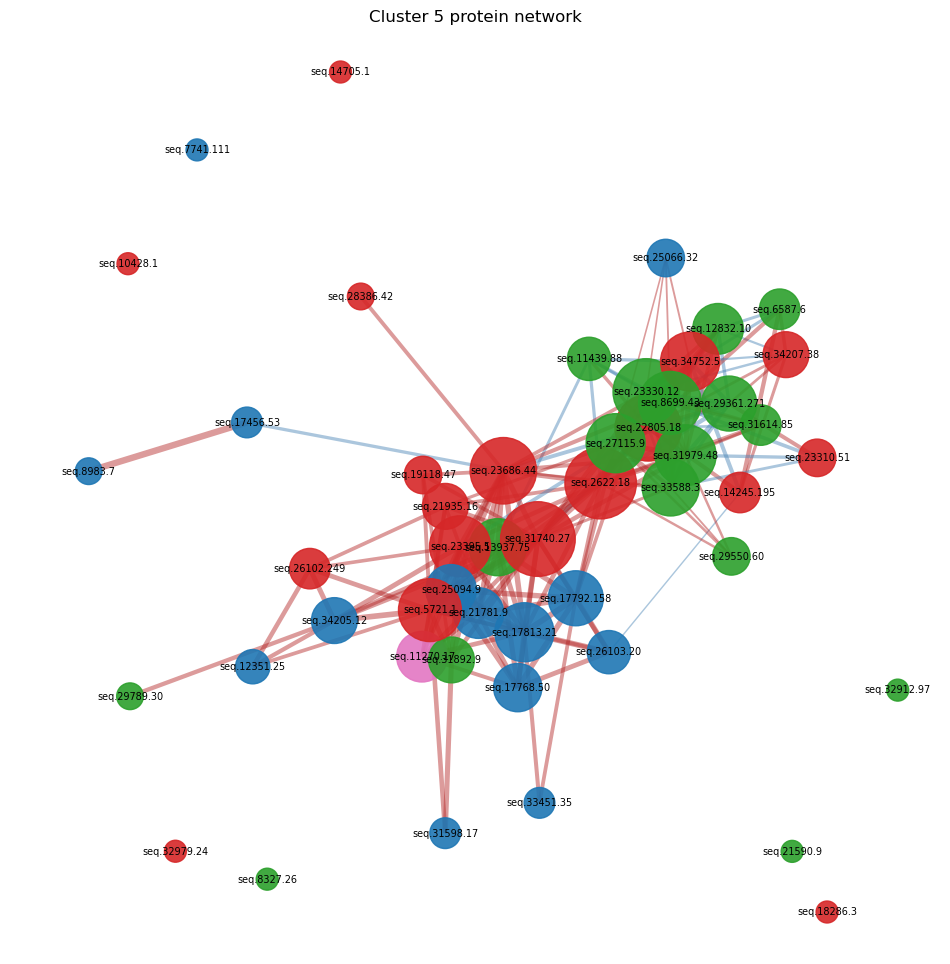

          protein method  degree
34   seq.31740.27     MI      22
26    seq.2622.18     MI      20
19   seq.23330.12     FS      17
17   seq.22805.18     MI      17
21   seq.23686.44     MI      17
48    seq.8699.43     FS      15
44     seq.5721.1     MI      15
36   seq.31979.48     FS      14
20    seq.23395.5     MI      14
27    seq.27115.9     FS      13
43    seq.34752.5     MI      13
11   seq.17813.21  ttest      13
5    seq.13937.75     FS      12
40    seq.33588.3     FS      12
29  seq.29361.271     FS      11
10  seq.17792.158  ttest      11
4    seq.12832.10     FS       9
1    seq.11270.17  MI,FS       9
15    seq.21781.9  ttest       9
23    seq.25094.9  ttest       9
9    seq.17768.50  ttest       8
35    seq.31892.9     FS       7
16   seq.21935.16     MI       7
42   seq.34207.38     MI       7
41   seq.34205.12  ttest       7
2    seq.11439.88     FS       6
25   seq.26103.20  ttest       6
33   seq.31614.85     FS       5
45     seq.6587.6     FS       5
6   seq.14

In [ ]:
# Nytt nätverk inom kluster 5 gemensam hög korrelation eller hög MI
corr_threshold = 0.7
mi_threshold = cluster5_pairs_df["mutual_information"].quantile(0.85)

edges_df = cluster5_pairs_df[
    (cluster5_pairs_df["abs_corr"] >= corr_threshold) |
    (cluster5_pairs_df["mutual_information"] >= mi_threshold)
].copy()

print("Antal edges i nätverket:", len(edges_df))

# -------------------------
# Bygg grafen
# -------------------------
G5 = nx.Graph()

# Lägg till alla proteiner som noder
for p in cluster5_proteins:
    method_str = ",".join(method_map[p])
    G5.add_node(p, method=method_str)

# Lägg till edges
for _, row in edges_df.iterrows():
    G5.add_edge(
        row["protein1"],
        row["protein2"],
        corr=row["corr"],
        abs_corr=row["abs_corr"],
        mi=row["mutual_information"]
    )

# -------------------------
# Färger efter metod
# -------------------------
node_colors = [
    color_map.get(G5.nodes[n]["method"], "grey")
    for n in G5.nodes()
]

# -------------------------
# Nodstorlek efter degree
# -------------------------
degree_dict = dict(G5.degree())
node_sizes = [
    250 + 120 * degree_dict[n]
    for n in G5.nodes()
]

# -------------------------
# Edge-bredd efter styrka
# -------------------------
edge_widths = [
    1 + 4 * d["abs_corr"]
    for _, _, d in G5.edges(data=True)
]

# Edge-färg: positiv/negativ korrelation
edge_colors = [
    "firebrick" if d["corr"] > 0 else "steelblue"
    for _, _, d in G5.edges(data=True)
]

# -------------------------
# Rita nätverket
# -------------------------
plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G5, seed=7, k=0.5)

nx.draw_networkx_nodes(
    G5,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    G5,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.45
)

nx.draw_networkx_labels(
    G5,
    pos,
    font_size=7
)

plt.title("Cluster 5 protein network")
plt.axis("off")
plt.show()

network_nodes_df = pd.DataFrame({
    "protein": list(G5.nodes()),
    "method": [G5.nodes[n]["method"] for n in G5.nodes()],
    "degree": [degree_dict[n] for n in G5.nodes()]
}).sort_values(["degree", "method"], ascending=[False, True])

print(network_nodes_df)

In [ ]:
betweenness_dict = nx.betweenness_centrality(G5)

bridge_df = pd.DataFrame({
    "protein": list(G5.nodes()),
    "method": [G5.nodes[n]["method"] for n in G5.nodes()],
    "degree": [degree_dict[n] for n in G5.nodes()],
    "betweenness": [betweenness_dict[n] for n in G5.nodes()]
}).sort_values(["betweenness", "degree"], ascending=[False, False])

print(bridge_df.head(15))

          protein method  degree  betweenness
21   seq.23686.44     MI      17     0.136024
34   seq.31740.27     MI      22     0.121368
26    seq.2622.18     MI      20     0.086871
44     seq.5721.1     MI      15     0.077886
17   seq.22805.18     MI      17     0.055400
19   seq.23330.12     FS      17     0.049075
41   seq.34205.12  ttest       7     0.039649
20    seq.23395.5     MI      14     0.036770
8    seq.17456.53  ttest       2     0.034014
48    seq.8699.43     FS      15     0.028392
11   seq.17813.21  ttest      13     0.027742
10  seq.17792.158  ttest      11     0.026175
36   seq.31979.48     FS      14     0.022163
27    seq.27115.9     FS      13     0.021976
5    seq.13937.75     FS      12     0.021569


In [ ]:
# Kolla överlapp med hub proteins top 10
hub_top10 = set(hub_5.head(10)["protein"])
network_nodes_top10 = set(network_nodes_df.head(10)["protein"])

overlap_top10 = hub_top10 & network_nodes_top10

print("Number of overlapping proteins:", len(overlap_top10))
print("Overlapping proteins:", sorted(overlap_top10))

Number of overlapping proteins: 5
Overlapping proteins: ['seq.23395.5', 'seq.23686.44', 'seq.31740.27', 'seq.5721.1', 'seq.8699.43']


Number of communities: 11
Sizes: [22, 18, 2, 1, 1, 1, 1, 1, 1, 1, 1]
         protein  community method  degree
0   seq.31740.27          1     MI      22
5   seq.23686.44          1     MI      17
10    seq.5721.1          1     MI      15
12   seq.23395.5          1     MI      14
11  seq.17813.21          1  ttest      13


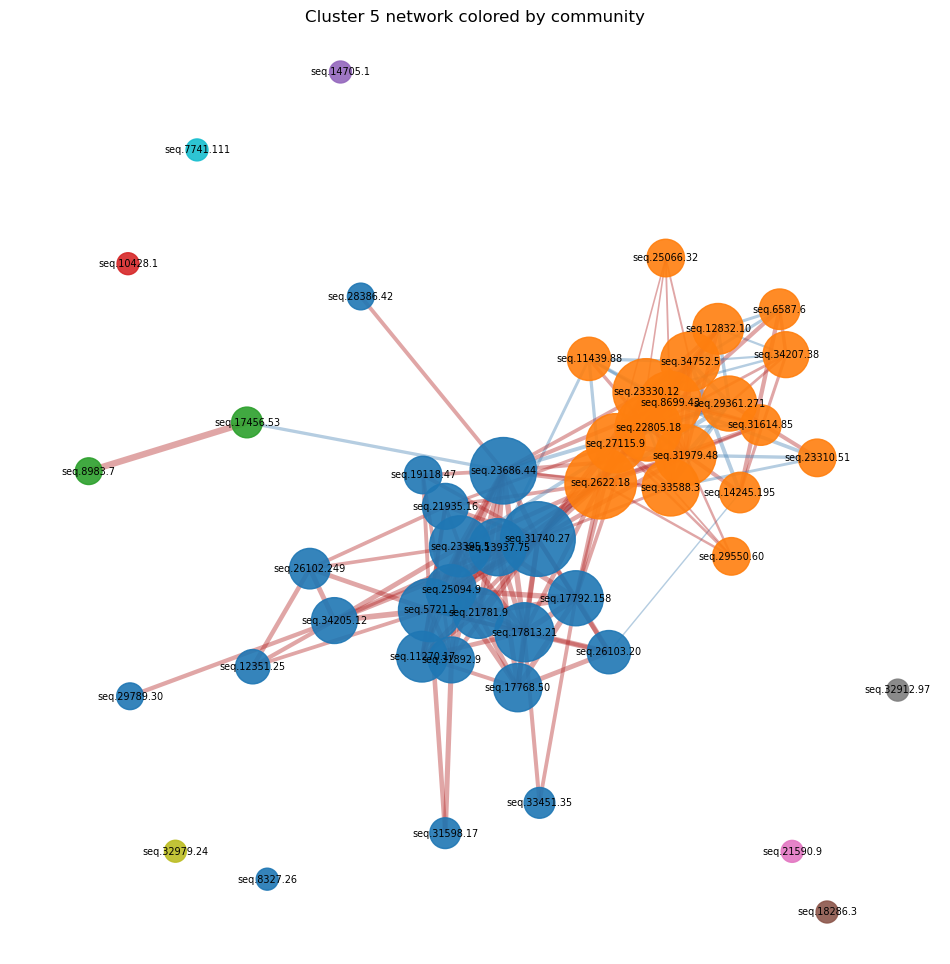

In [ ]:
# Community detection inom kluster 5 
from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G5))
print("Number of communities:", len(communities))
print("Sizes:", [len(c) for c in communities])
community_rows = []

for i, comm in enumerate(communities, start=1):
    for protein in comm:
        community_rows.append({
            "protein": protein,
            "community": i,
            "method": G5.nodes[protein]["method"],
            "degree": G5.degree(protein)
        })

community_df = pd.DataFrame(community_rows).sort_values(
    ["community", "degree"],
    ascending=[True, False]
)

print(community_df.head(5))
community_method_counts = (
    community_df.groupby("community")["method"]
    .value_counts()
)

# mappa protein -> community
protein_to_community = {}
for i, comm in enumerate(communities, start=1):
    for protein in comm:
        protein_to_community[protein] = i

# färger för communities
unique_communities = sorted(set(protein_to_community.values()))
community_palette = {
    c: plt.cm.tab10((c - 1) % 10) for c in unique_communities
}

node_colors_comm = [
    community_palette[protein_to_community[n]]
    for n in G5.nodes()
]

degree_dict = dict(G5.degree())
node_sizes = [250 + 120 * degree_dict[n] for n in G5.nodes()]

edge_widths = [
    1 + 4 * d["abs_corr"]
    for _, _, d in G5.edges(data=True)
]

edge_colors = [
    "firebrick" if d["corr"] > 0 else "steelblue"
    for _, _, d in G5.edges(data=True)
]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G5, seed=7, k=0.5)

nx.draw_networkx_nodes(
    G5,
    pos,
    node_color=node_colors_comm,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    G5,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.4
)

nx.draw_networkx_labels(
    G5,
    pos,
    font_size=7
)

plt.title("Cluster 5 network colored by community")
plt.axis("off")
plt.show()

In [ ]:
# Keep only Cluster 5 proteins included in communities 1, 2, 3
communities_to_keep = [1, 2, 3]

proteins_to_keep = set(
    community_df.loc[community_df["community"].isin(communities_to_keep), "protein"]
)

cluster5_reduced_df = (
    cluster5[cluster5["protein"].isin(proteins_to_keep)]
    .merge(
        community_df[["protein", "community"]],
        on="protein",
        how="left"
    )
    .drop_duplicates(subset=["protein"])
    .sort_values(["community", "protein"])
    .reset_index(drop=True)
)

print("Proteins kept:", len(cluster5_reduced_df))
cluster5_reduced_df

Proteins kept: 42


,protein,cluster,method,community
0,seq.11270.17,5,"MI,FS",1
1,seq.12351.25,5,ttest,1
2,seq.13937.75,5,FS,1
3,seq.17768.50,5,ttest,1
4,seq.17792.158,5,ttest,1
5,seq.17813.21,5,ttest,1
6,seq.19118.47,5,MI,1
7,seq.21781.9,5,ttest,1
8,seq.21935.16,5,MI,1
9,seq.23395.5,5,MI,1


# PCA på kluster 5
42 proteiner med 3 communities

In [ ]:
# X_scaled with only proteins in cluster_5
cluster5new = cluster5_reduced_df.copy()
cluster5_cols = cluster5new["protein"].tolist()
cluster5_cols = [p for p in cluster5_cols if p in X_scaled.columns]

X_scaled_5 = X_scaled[cluster5_cols].copy()

print(X_scaled_5.shape)
X_scaled_5.head()

(408, 42)


,seq.11270.17,seq.12351.25,seq.13937.75,seq.17768.50,seq.17792.158,seq.17813.21,seq.19118.47,seq.21781.9,seq.21935.16,seq.23395.5,...,seq.29550.60,seq.31614.85,seq.31979.48,seq.33588.3,seq.34207.38,seq.34752.5,seq.6587.6,seq.8699.43,seq.17456.53,seq.8983.7
0,-1.742445,0.495010,0.024868,-0.613584,-0.083559,-0.622150,-0.925337,-0.631758,0.016480,-0.383454,...,-0.190931,-0.571268,-0.320352,-0.070623,-0.217722,-0.038215,0.000876,-0.299323,-0.202715,-0.439474
1,-1.420258,-0.253577,1.893010,-0.429132,-0.325606,-0.780133,-0.528077,-0.251232,-1.041306,1.197806,...,-0.335759,-0.850511,0.246463,-0.672150,-1.178686,-0.302195,-1.578181,-0.548180,-1.113459,-1.584860
2,1.500467,0.805885,2.033741,2.300277,2.557199,0.977958,0.318085,1.222263,-0.139686,1.449303,...,-0.467546,-0.398559,0.856640,-0.286880,-0.269293,0.047016,-0.907211,-0.151456,-1.627186,-1.885341
3,-0.702104,0.841492,-0.396449,-0.545810,0.341283,0.024946,0.038198,0.189332,-0.464664,-0.093646,...,-0.055982,-1.264819,-0.994988,-0.702035,0.278451,0.334425,1.082757,-1.210164,-0.327750,-0.594398
4,2.573650,-1.844991,0.297649,-0.252502,-0.381859,-0.230882,-0.212855,-0.203604,0.334220,1.092723,...,-0.331084,-0.373470,0.800011,0.060980,0.366721,0.360228,-0.207762,0.663990,-1.572725,-1.508496


In [ ]:
from sklearn.decomposition import PCA

# PCA on all proteins in X_scaled_5
pca = PCA()
pcs = pca.fit_transform(X_scaled_5)
pc1 = pcs[:, 0]
print("PC1 explained variance (all):", pca.explained_variance_ratio_[0])

# PCA explained variance for communities 1, 2, 3
community_scores = {}

for c in [1, 2, 3]:
    proteins = cluster5_reduced_df.loc[cluster5_reduced_df["community"] == c, "protein"]
    proteins = [p for p in proteins if p in X_scaled_5.columns]

    if len(proteins) >= 2:
        Xc = X_scaled_5[proteins]
        score = PCA().fit(Xc).explained_variance_ratio_[0]
        community_scores[c] = score
    else:
        community_scores[c] = np.nan

print(pd.Series(community_scores, name="pc1_explained_variance"))

print(len(cluster5_reduced_df[cluster5_reduced_df["community"] == 1]), len(cluster5_reduced_df[cluster5_reduced_df["community"] == 2]), len(cluster5_reduced_df[cluster5_reduced_df["community"] == 3]))

PC1 explained variance (all): 0.31792556823065127
1    0.445354
2    0.384088
3    0.953648
Name: pc1_explained_variance, dtype: float64
22 18 2


In [ ]:
from scipy.stats import ttest_ind
y = realdata['ards']

for c in community_scores:
    proteins = cluster5_reduced_df.loc[
        cluster5_reduced_df["community"] == c,
        "protein"
    ]

    Xc = X_scaled_5[proteins]

    pc1 = PCA(n_components=1).fit_transform(Xc)[:,0]

    stat, p = ttest_ind(pc1[y==1], pc1[y==0])

    print("Community", c, "p-value:", p)


Community 1 p-value: 0.47006445905842054
Community 2 p-value: 0.5017189170036318
Community 3 p-value: 2.6853005903743364e-05


# Beteenden kluster 5

Top 5 correlation pairs:
         protein1      protein2      corr  abs_corr  mutual_information
3    seq.13937.75  seq.31740.27  0.799205  0.799205            0.580075
33  seq.17792.158  seq.17813.21  0.790987  0.790987            0.380130
13    seq.23395.5  seq.23686.44  0.768207  0.768207            0.474417
29    seq.23395.5  seq.31740.27  0.767641  0.767641            0.395922
49   seq.17813.21  seq.26103.20  0.764040  0.764040            0.321394

Top 5 MI pairs:
        protein1      protein2      corr  abs_corr  mutual_information
3   seq.13937.75  seq.31740.27  0.799205  0.799205            0.580075
10  seq.34205.12    seq.5721.1  0.763929  0.763929            0.501882
11   seq.23395.5    seq.5721.1  0.750518  0.750518            0.488484
13   seq.23395.5  seq.23686.44  0.768207  0.768207            0.474417
20  seq.31740.27    seq.5721.1  0.718656  0.718656            0.447954

Lowest 5 correlation pairs:
           protein1      protein2      corr  abs_corr  mutual_informati

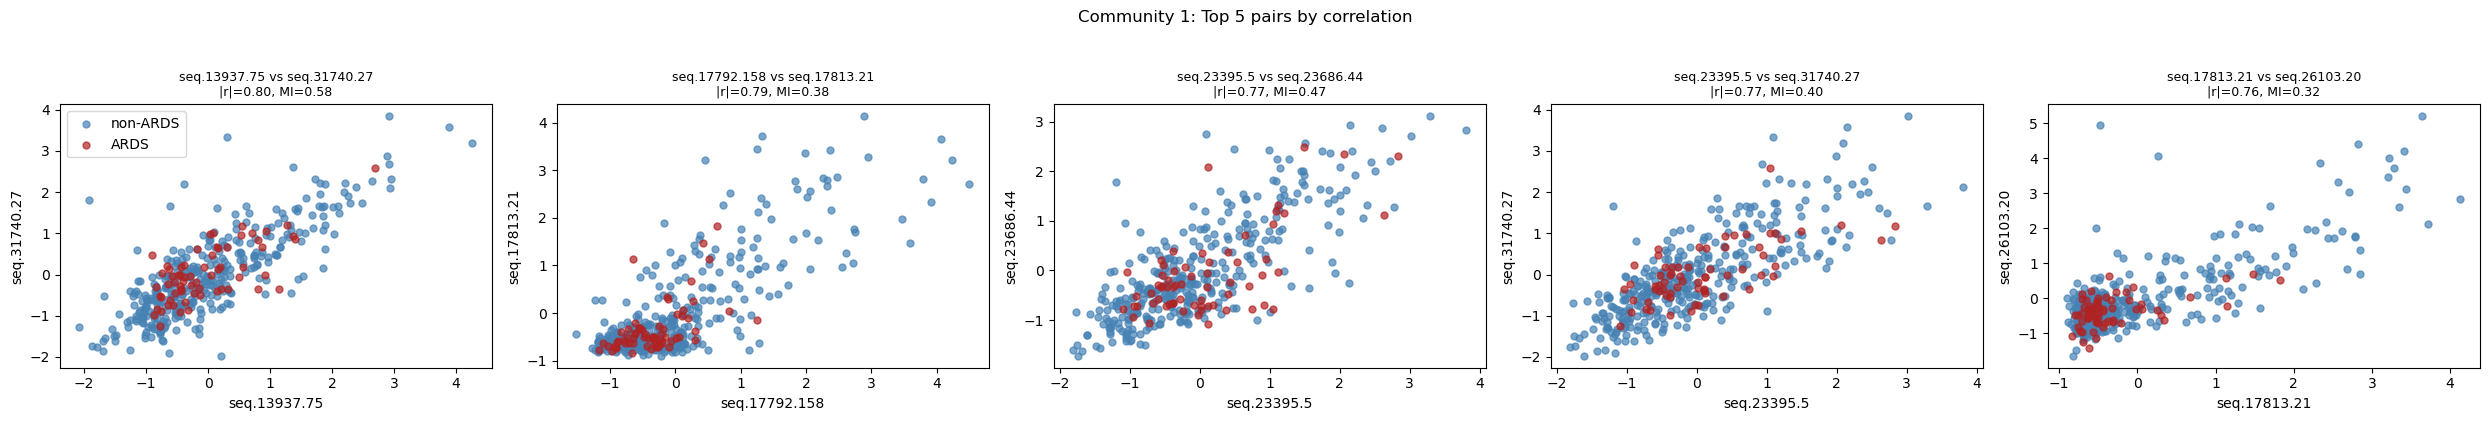

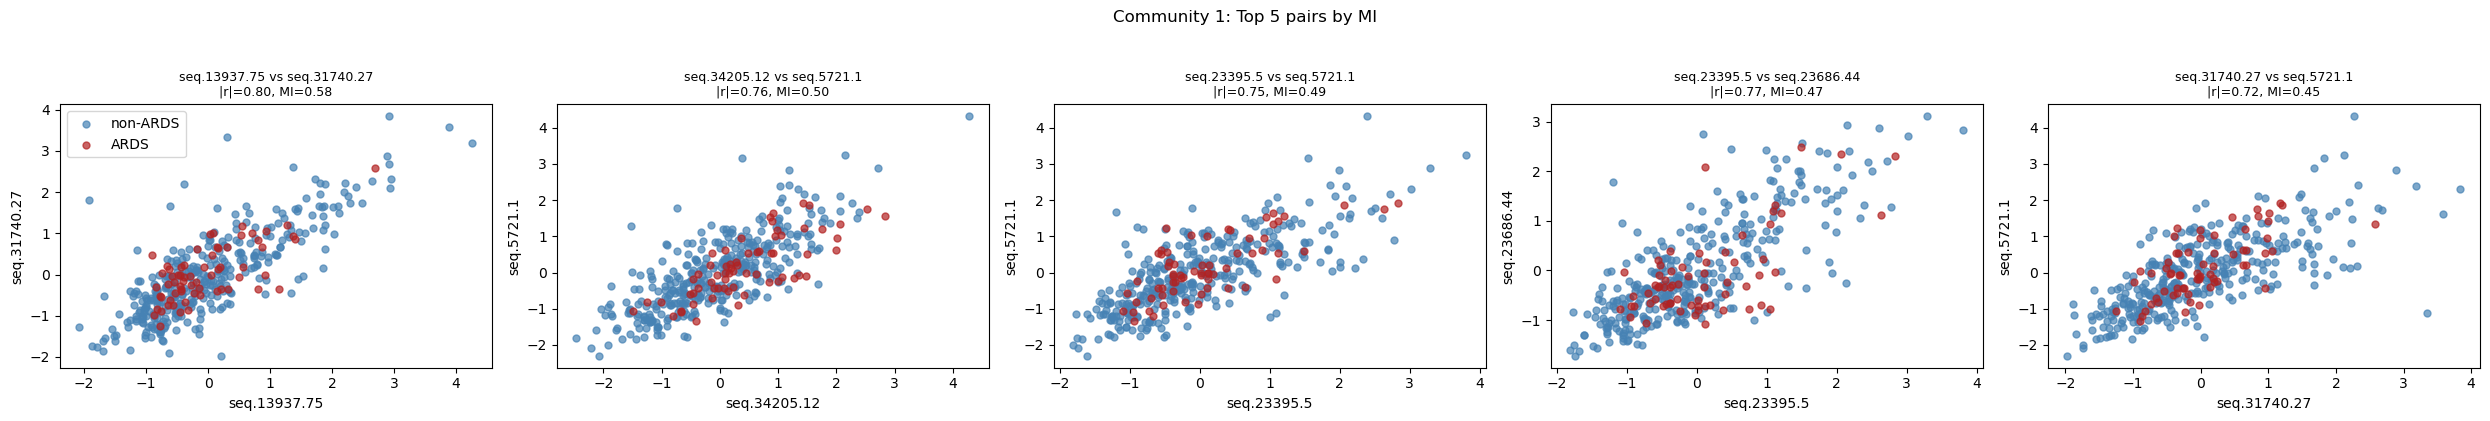

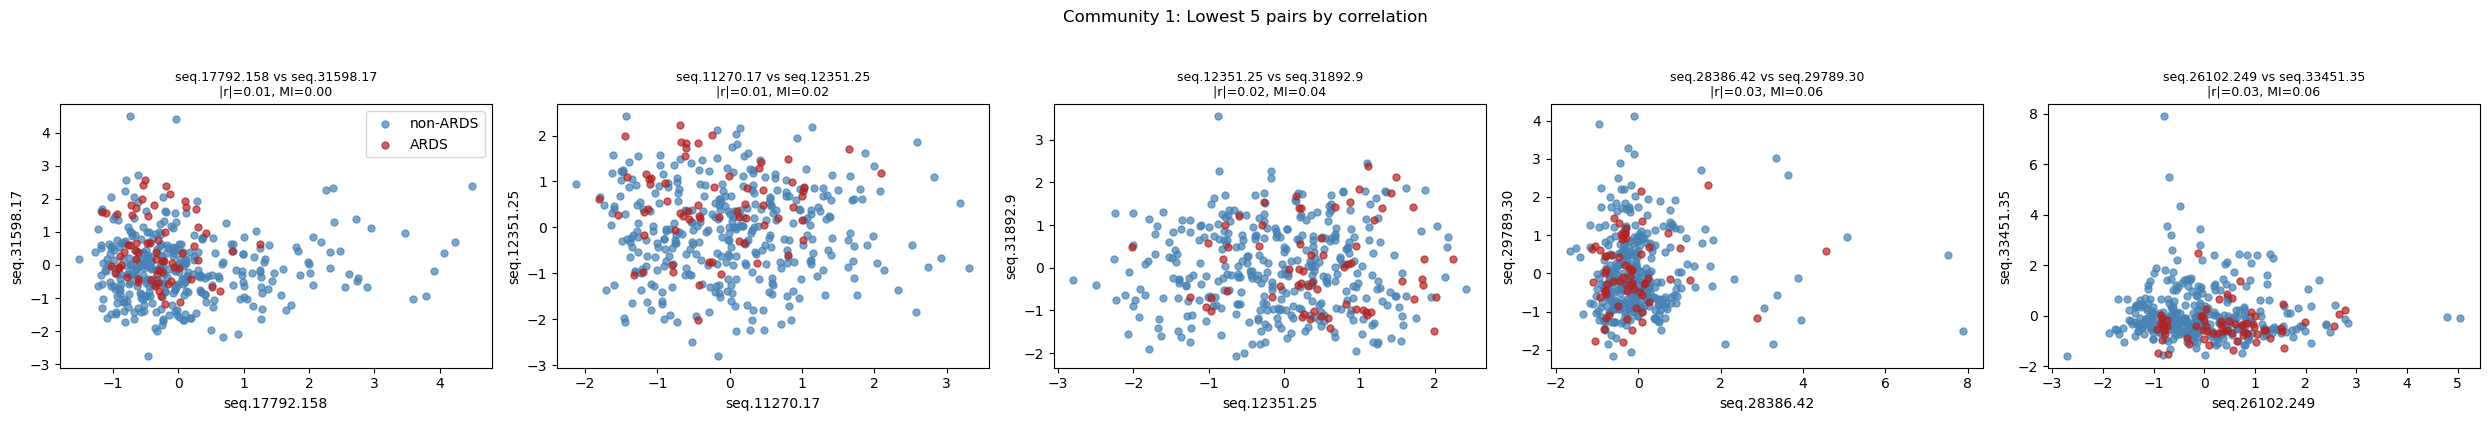

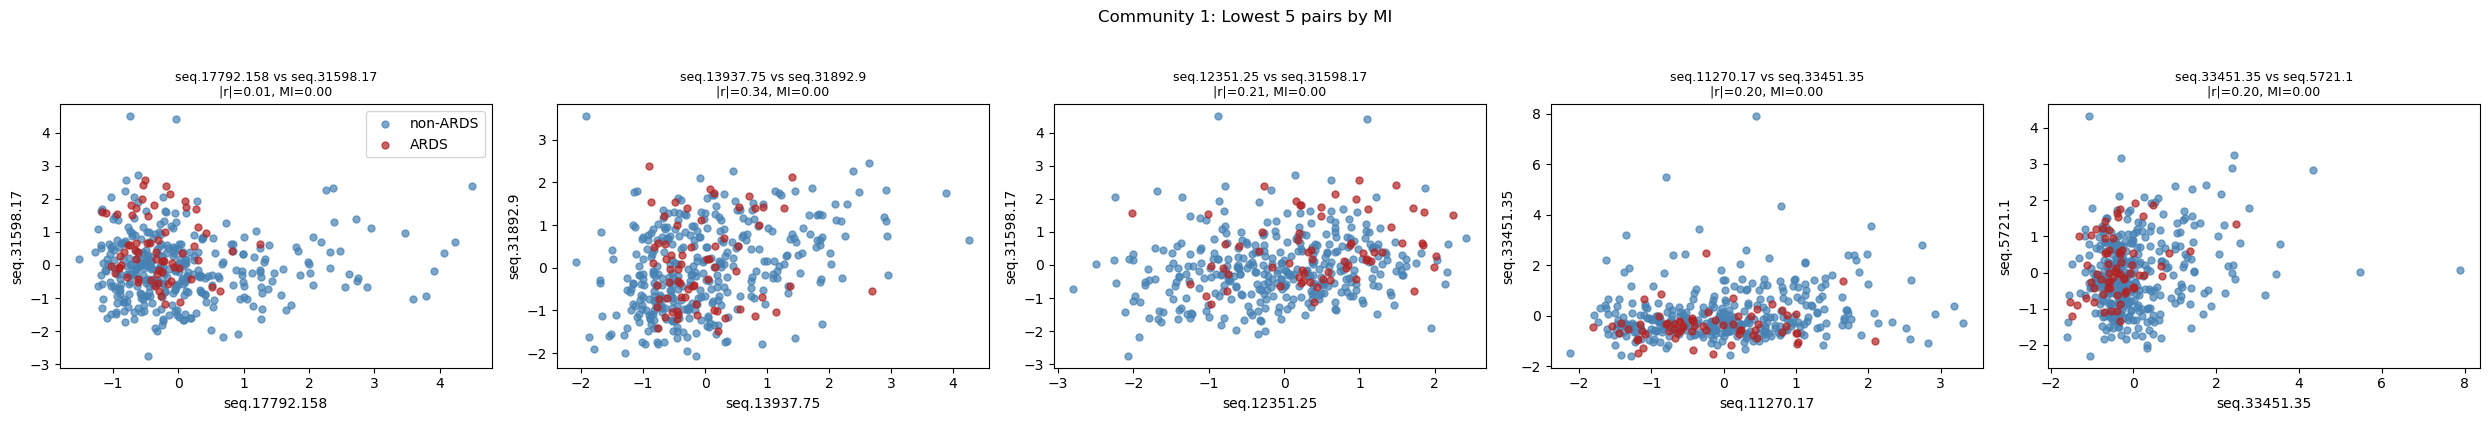

In [ ]:
community = 1
proteins = set(
    cluster5_reduced_df.loc[cluster5_reduced_df["community"] == community, "protein"]
)

pairs_comm = cluster5_pairs_df[
    cluster5_pairs_df["protein1"].isin(proteins) &
    cluster5_pairs_df["protein2"].isin(proteins)
]

top5_corr = pairs_comm.sort_values("abs_corr", ascending=False).head(5).copy()
top5_mi = pairs_comm.sort_values("mutual_information", ascending=False).head(5).copy()
low5_corr = pairs_comm.sort_values("abs_corr", ascending=True).head(5).copy()
low5_mi = pairs_comm.sort_values("mutual_information", ascending=True).head(5).copy()

print("Top 5 correlation pairs:")
print(top5_corr[["protein1", "protein2", "corr", "abs_corr", "mutual_information"]])
print("\nTop 5 MI pairs:")
print(top5_mi[["protein1", "protein2", "corr", "abs_corr", "mutual_information"]])
print("\nLowest 5 correlation pairs:")
print(low5_corr[["protein1", "protein2", "corr", "abs_corr", "mutual_information"]])
print("\nLowest 5 MI pairs:")
print(low5_mi[["protein1", "protein2", "corr", "abs_corr", "mutual_information"]])

y_ards = realdata["ards"].to_numpy()
mask_ards = y_ards == 1
mask_non_ards = y_ards == 0

def plot_pair_scatter(pairs_df, title_prefix):
    n = len(pairs_df)
    if n == 0:
        print(f"No pairs found for {title_prefix}.")
        return

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    axes = axes[0]

    for idx, (_, row) in enumerate(pairs_df.iterrows()):
        p1, p2 = row["protein1"], row["protein2"]
        x = X_scaled_5[p1].to_numpy()
        y = X_scaled_5[p2].to_numpy()

        ax = axes[idx]
        ax.scatter(x[mask_non_ards], y[mask_non_ards], s=25, alpha=0.7, color="steelblue", label="non-ARDS")
        ax.scatter(x[mask_ards], y[mask_ards], s=25, alpha=0.7, color="firebrick", label="ARDS")

        metric_text = f"|r|={row['abs_corr']:.2f}, MI={row['mutual_information']:.2f}"
        ax.set_title(f"{p1} vs {p2}\n{metric_text}", fontsize=9)
        ax.set_xlabel(p1)
        ax.set_ylabel(p2)

        if idx == 0:
            ax.legend(title="")

    plt.suptitle(f"Community {community}: {title_prefix}", y=1.04)
    plt.tight_layout()
    plt.show()

plot_pair_scatter(top5_corr, "Top 5 pairs by correlation")
plot_pair_scatter(top5_mi, "Top 5 pairs by MI")
plot_pair_scatter(low5_corr, "Lowest 5 pairs by correlation")
plot_pair_scatter(low5_mi, "Lowest 5 pairs by MI")

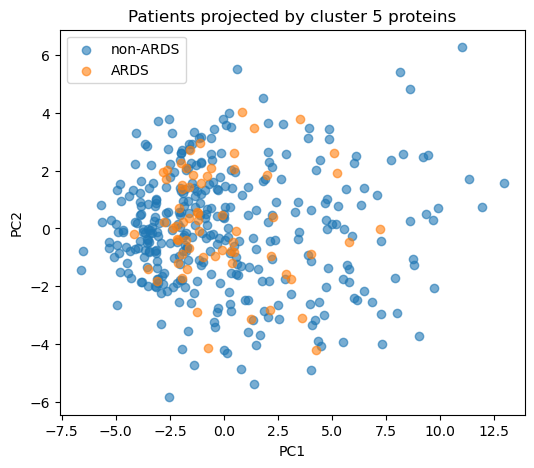

In [ ]:
# PCA på hela klustret mot ARDS
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled_5)

pc1 = pcs[:,0]
pc2 = pcs[:,1]

plt.figure(figsize=(6,5))

plt.scatter(pc1[y==0], pc2[y==0], alpha=0.6, label="non-ARDS")
plt.scatter(pc1[y==1], pc2[y==1], alpha=0.6, label="ARDS")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patients projected by cluster 5 proteins")
plt.legend()
plt.show()

In [ ]:
# Random forest på hela klustret
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_scaled_5, y)

importances = pd.Series(
    rf.feature_importances_,
    index=X_scaled_5.columns
).sort_values(ascending=False)

print(importances.head(15))

# jämför med hub proteins
top10_rf = set(importances.head(10).index)
overlap = hub_top10 & top10_rf
print("Överlapp med hub proteiner:", len(overlap))
print(overlap)

# Correlations of the top RF features


seq.34205.12     0.041752
seq.31598.17     0.040222
seq.26102.249    0.039966
seq.12351.25     0.038681
seq.17456.53     0.032112
seq.26103.20     0.032063
seq.8983.7       0.030085
seq.33451.35     0.029762
seq.23310.51     0.027264
seq.27115.9      0.026984
seq.31614.85     0.026650
seq.21781.9      0.026626
seq.25094.9      0.025797
seq.28386.42     0.024869
seq.17768.50     0.024081
dtype: float64
Överlapp med hub proteiner: 1
{'seq.8983.7'}


In [ ]:
# shap values
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_scaled_5)

# Handle SHAP output format across versions
# - list (older): [class0, class1]
# - ndarray (newer): (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

print("SHAP matrix shape:", np.asarray(shap_vals).shape)

/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP matrix shape: (408, 42)


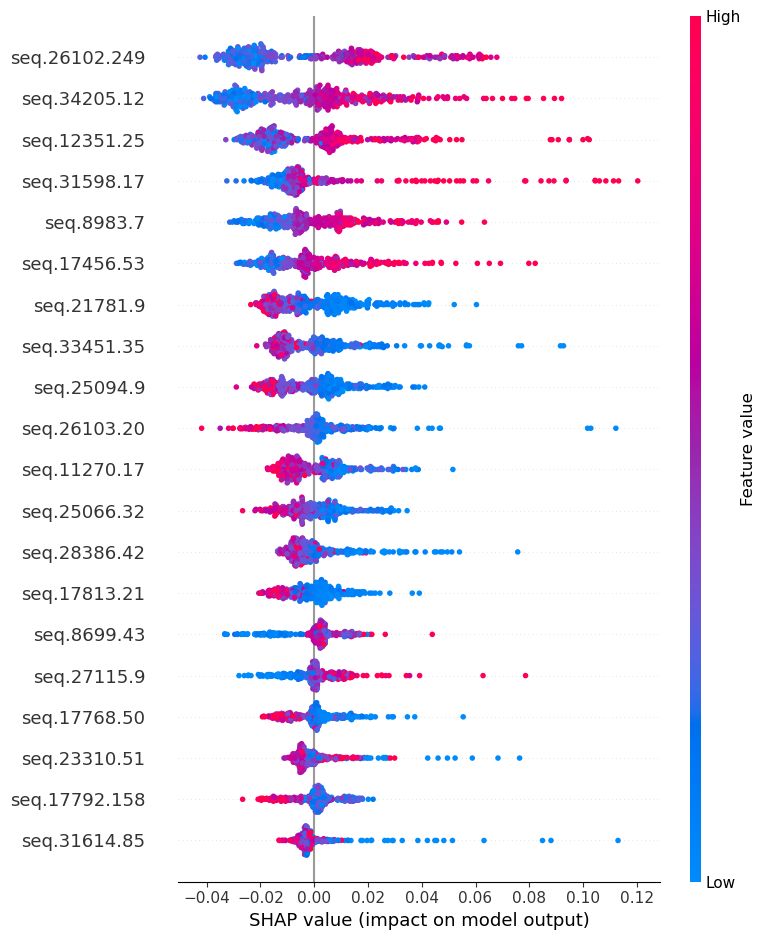

In [ ]:
shap.summary_plot(
    shap_vals,
    X_scaled_5,
    plot_type="dot"
)

In [ ]:
shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_scaled_5.columns
).sort_values(ascending=False)

print(shap_importance.head(10))
print(set(shap_importance.head(10).index) & set(hub_top10))

seq.26102.249    0.023848
seq.34205.12     0.020043
seq.12351.25     0.017076
seq.31598.17     0.014120
seq.8983.7       0.012949
seq.17456.53     0.012514
seq.21781.9      0.011950
seq.33451.35     0.011358
seq.25094.9      0.010702
seq.26103.20     0.009510
dtype: float64
{'seq.25094.9', 'seq.8983.7'}


Using labels from: y
Class mapping -> non-ARDS: False, ARDS: True
n(non-ARDS)=343, n(ARDS)=65


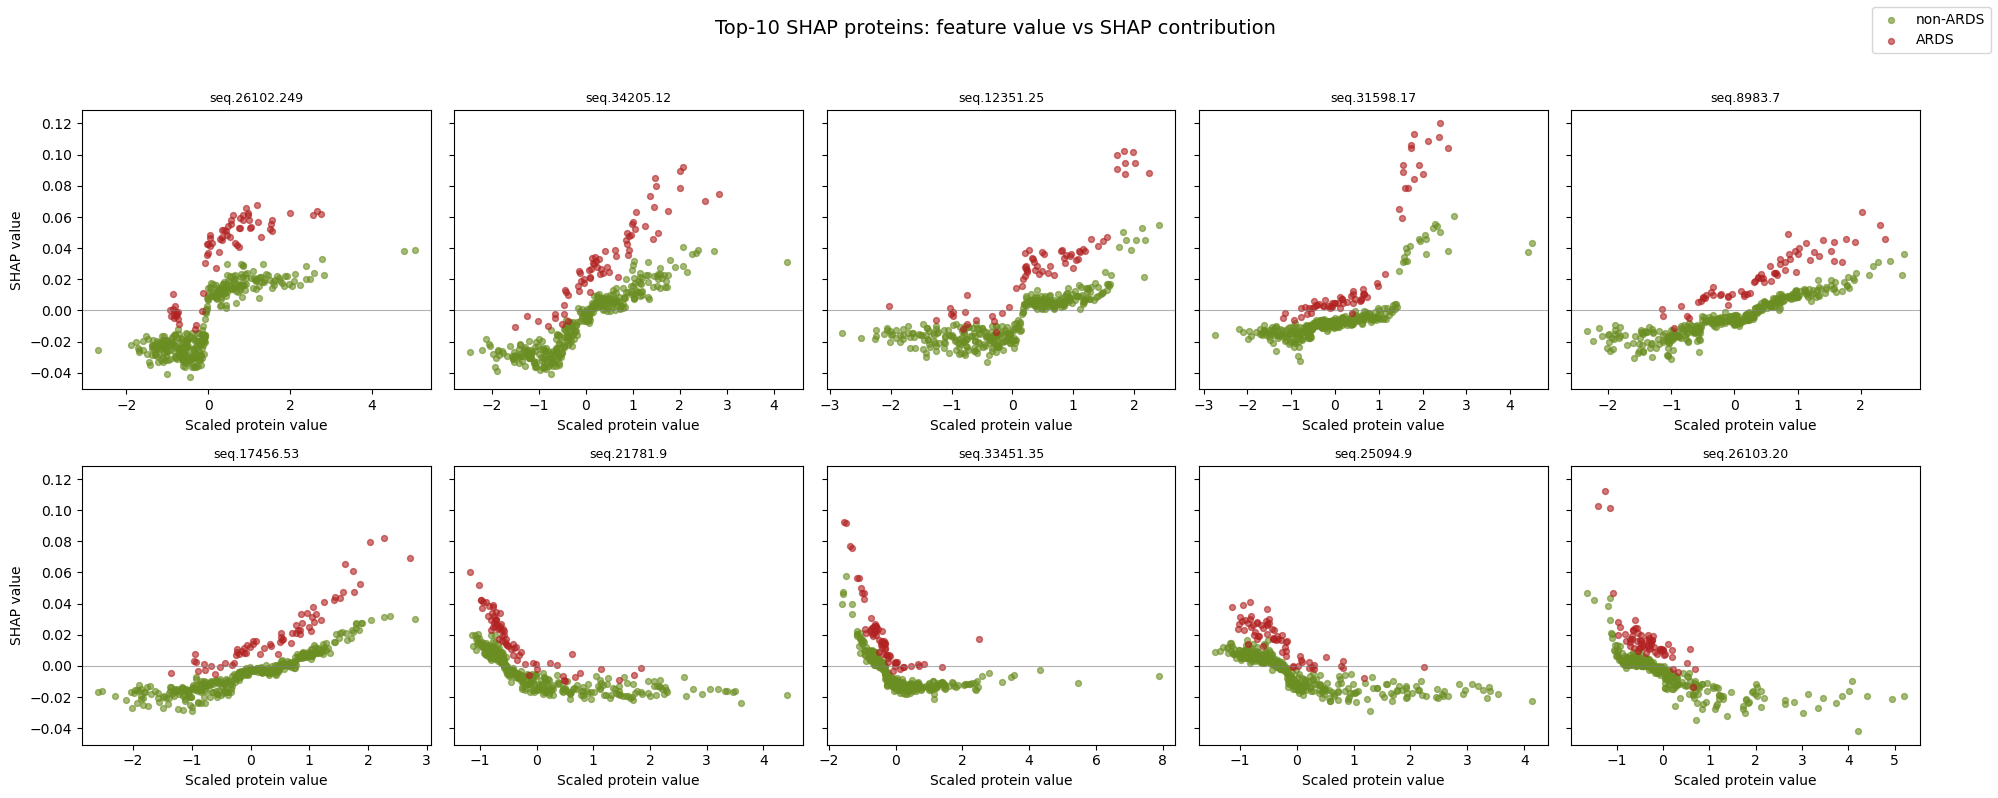

In [ ]:
# Scatter plots of top 10 SHAP features (ARDS vs non-ARDS)
top10_shap = shap_importance.head(10).index.tolist()
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

# Pick a valid binary label vector (y may have been overwritten elsewhere in notebook)
label_candidates = {
    "y_true": globals().get("y_true", None),
    "ards_label": globals().get("ards_label", None),
    "y": globals().get("y", None),
}

y_labels = None
label_source = None
for name, candidate in label_candidates.items():
    if candidate is None:
        continue
    s = pd.Series(np.asarray(candidate).ravel())
    uniq = pd.unique(s.dropna())
    if len(uniq) == 2:
        y_labels = s
        label_source = name
        break

if y_labels is None:
    raise ValueError(
        "Could not find a binary label vector among y_true, ards_label, y. "
        "Please ensure one of them contains ARDS/non-ARDS labels."
    )

classes = np.sort(pd.unique(y_labels.dropna()))
non_ards_val, ards_val = classes[0], classes[1]
mask_non_ards = (y_labels == non_ards_val).to_numpy()
mask_ards = (y_labels == ards_val).to_numpy()

print(f"Using labels from: {label_source}")
print(f"Class mapping -> non-ARDS: {non_ards_val}, ARDS: {ards_val}")
print(f"n(non-ARDS)={mask_non_ards.sum()}, n(ARDS)={mask_ards.sum()}")

# Global y-range for consistent comparison across proteins
top10_idx = [X_scaled_5.columns.get_loc(f) for f in top10_shap]
y_min = np.min(shap_vals[:, top10_idx])
y_max = np.max(shap_vals[:, top10_idx])
y_pad = 0.05 * (y_max - y_min + 1e-12)

for i, feature in enumerate(top10_shap):
    ax = axes[i]
    feature_idx = X_scaled_5.columns.get_loc(feature)

    x = X_scaled_5[feature].to_numpy()
    y_shap = shap_vals[:, feature_idx]

    ax.scatter(
        x[mask_non_ards],
        y_shap[mask_non_ards],
        color="olivedrab",
        alpha=0.6,
        s=18,
        label="non-ARDS" if i == 0 else None,
    )
    ax.scatter(
        x[mask_ards],
        y_shap[mask_ards],
        color="firebrick",
        alpha=0.6,
        s=18,
        label="ARDS" if i == 0 else None,
    )

    ax.axhline(0, color="grey", linewidth=0.8, alpha=0.6)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel("Scaled protein value")
    if i % 5 == 0:
        ax.set_ylabel("SHAP value")

fig.suptitle("Top-10 SHAP proteins: feature value vs SHAP contribution", fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout(rect=[0, 0, 0.97, 0.95])
plt.show()

Using labels from: y
Class mapping -> non-ARDS: False, ARDS: True
n(non-ARDS)=343, n(ARDS)=65


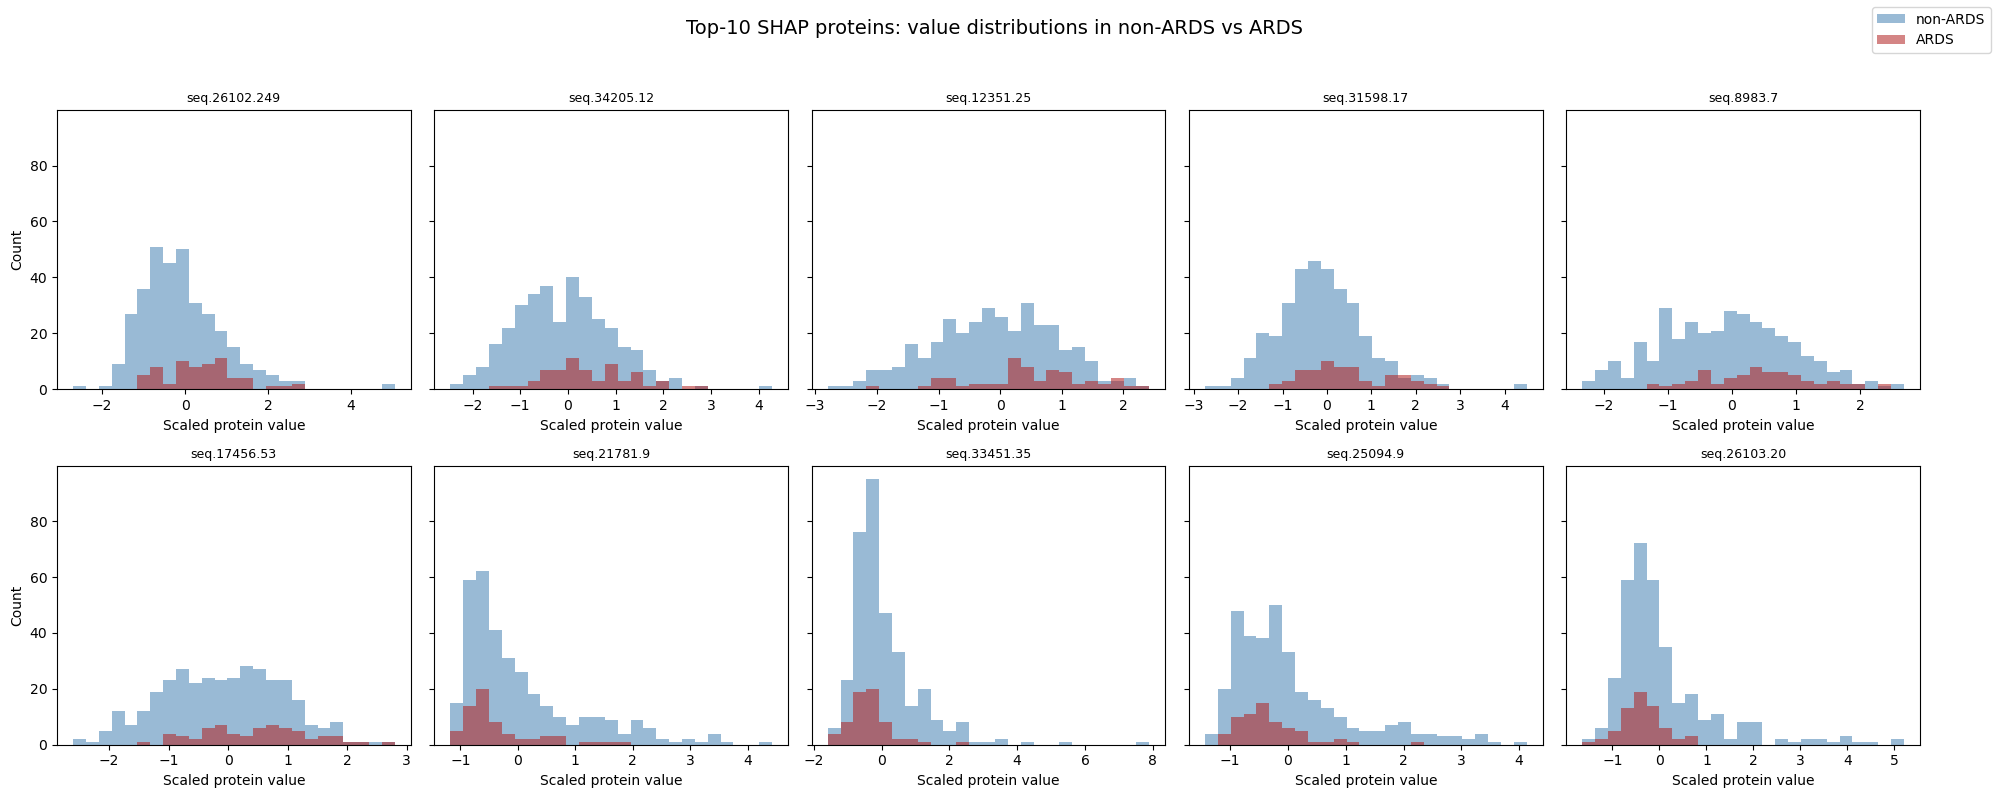

In [ ]:
# Histograms of top 10 SHAP proteins (ARDS vs non-ARDS)

top10_shap = shap_importance.head(10).index.tolist()
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

# Robust binary label selection (y may be overwritten)
label_candidates = {
    "y_true": globals().get("y_true", None),
    "ards_label": globals().get("ards_label", None),
    "y": globals().get("y", None),
}

y_labels = None
label_source = None
for name, candidate in label_candidates.items():
    if candidate is None:
        continue
    s = pd.Series(np.asarray(candidate).ravel())
    uniq = pd.unique(s.dropna())
    if len(uniq) == 2:
        y_labels = s
        label_source = name
        break

if y_labels is None:
    raise ValueError(
        "Could not find a binary label vector among y_true, ards_label, y."
    )

classes = np.sort(pd.unique(y_labels.dropna()))
non_ards_val, ards_val = classes[0], classes[1]
mask_non_ards = (y_labels == non_ards_val).to_numpy()
mask_ards = (y_labels == ards_val).to_numpy()

print(f"Using labels from: {label_source}")
print(f"Class mapping -> non-ARDS: {non_ards_val}, ARDS: {ards_val}")
print(f"n(non-ARDS)={mask_non_ards.sum()}, n(ARDS)={mask_ards.sum()}")

for i, feature in enumerate(top10_shap):
    ax = axes[i]
    vals = X_scaled_5[feature].to_numpy()

    # Shared bins per subplot so groups are directly comparable
    bins = np.histogram_bin_edges(vals, bins=25)

    ax.hist(
        vals[mask_non_ards],
        bins=bins,
        color="steelblue",
        alpha=0.55,
        label="non-ARDS" if i == 0 else None,
        density=False,
    )
    ax.hist(
        vals[mask_ards],
        bins=bins,
        color="firebrick",
        alpha=0.55,
        label="ARDS" if i == 0 else None,
        density=False,
    )

    ax.set_title(feature, fontsize=9)
    ax.set_xlabel("Scaled protein value")
    if i % 5 == 0:
        ax.set_ylabel("Count")

fig.suptitle("Top-10 SHAP proteins: value distributions in non-ARDS vs ARDS", fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout(rect=[0, 0, 0.97, 0.95])
plt.show()

In [ ]:
# Shap interactions
shap_interaction = explainer.shap_interaction_values(X_scaled_5)

In [ ]:
# Normalize SHAP interaction output shape across SHAP versions
# - list (older): [class0, class1], each (n_samples, n_features, n_features)
# - ndarray (newer): (n_samples, n_features, n_features, n_classes)
# - ndarray (regression/single output): (n_samples, n_features, n_features)
if isinstance(shap_interaction, list):
    interaction_vals = shap_interaction[1]
elif isinstance(shap_interaction, np.ndarray) and shap_interaction.ndim == 4:
    interaction_vals = shap_interaction[:, :, :, 1]
elif isinstance(shap_interaction, np.ndarray) and shap_interaction.ndim == 3:
    interaction_vals = shap_interaction
else:
    raise ValueError(f"Unexpected shap_interaction shape: {np.asarray(shap_interaction).shape}")

interaction_strength = np.abs(interaction_vals).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_strength,
    index=X_scaled_5.columns,
    columns=X_scaled_5.columns
)

# ta bort diagonalen
np.fill_diagonal(interaction_df.values, 0)

interaction_df = interaction_df.where(
    np.triu(np.ones(interaction_df.shape), k=1).astype(bool)
)

interaction_df.stack().sort_values(ascending=False).head(20)

seq.17456.53   seq.8983.7       0.001605
seq.21935.16   seq.26102.249    0.001163
seq.26102.249  seq.26103.20     0.001068
seq.34205.12   seq.17456.53     0.001065
seq.26103.20   seq.34205.12     0.001062
seq.26102.249  seq.34205.12     0.001002
seq.21781.9    seq.26102.249    0.000984
seq.25094.9    seq.34205.12     0.000963
seq.12351.25   seq.25066.32     0.000961
seq.26102.249  seq.17456.53     0.000952
seq.12351.25   seq.31598.17     0.000940
seq.26102.249  seq.8983.7       0.000892
seq.21781.9    seq.34205.12     0.000883
seq.11270.17   seq.26102.249    0.000814
seq.12351.25   seq.26103.20     0.000781
               seq.17768.50     0.000772
seq.34205.12   seq.27115.9      0.000771
seq.17768.50   seq.34205.12     0.000771
seq.25094.9    seq.31598.17     0.000755
               seq.26102.249    0.000751
dtype: float64

In [ ]:
top_interactions_from_shap = (
    interaction_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "protein1", "level_1": "protein2", 0: "interaction_strength"})
    .sort_values("interaction_strength", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

top_interactions_from_shap

,protein1,protein2,interaction_strength
0,seq.17456.53,seq.8983.7,0.001605
1,seq.21935.16,seq.26102.249,0.001163
2,seq.26102.249,seq.26103.20,0.001068
3,seq.34205.12,seq.17456.53,0.001065
4,seq.26103.20,seq.34205.12,0.001062
5,seq.26102.249,seq.34205.12,0.001002
6,seq.21781.9,seq.26102.249,0.000984
7,seq.25094.9,seq.34205.12,0.000963
8,seq.12351.25,seq.25066.32,0.000961
9,seq.26102.249,seq.17456.53,0.000952


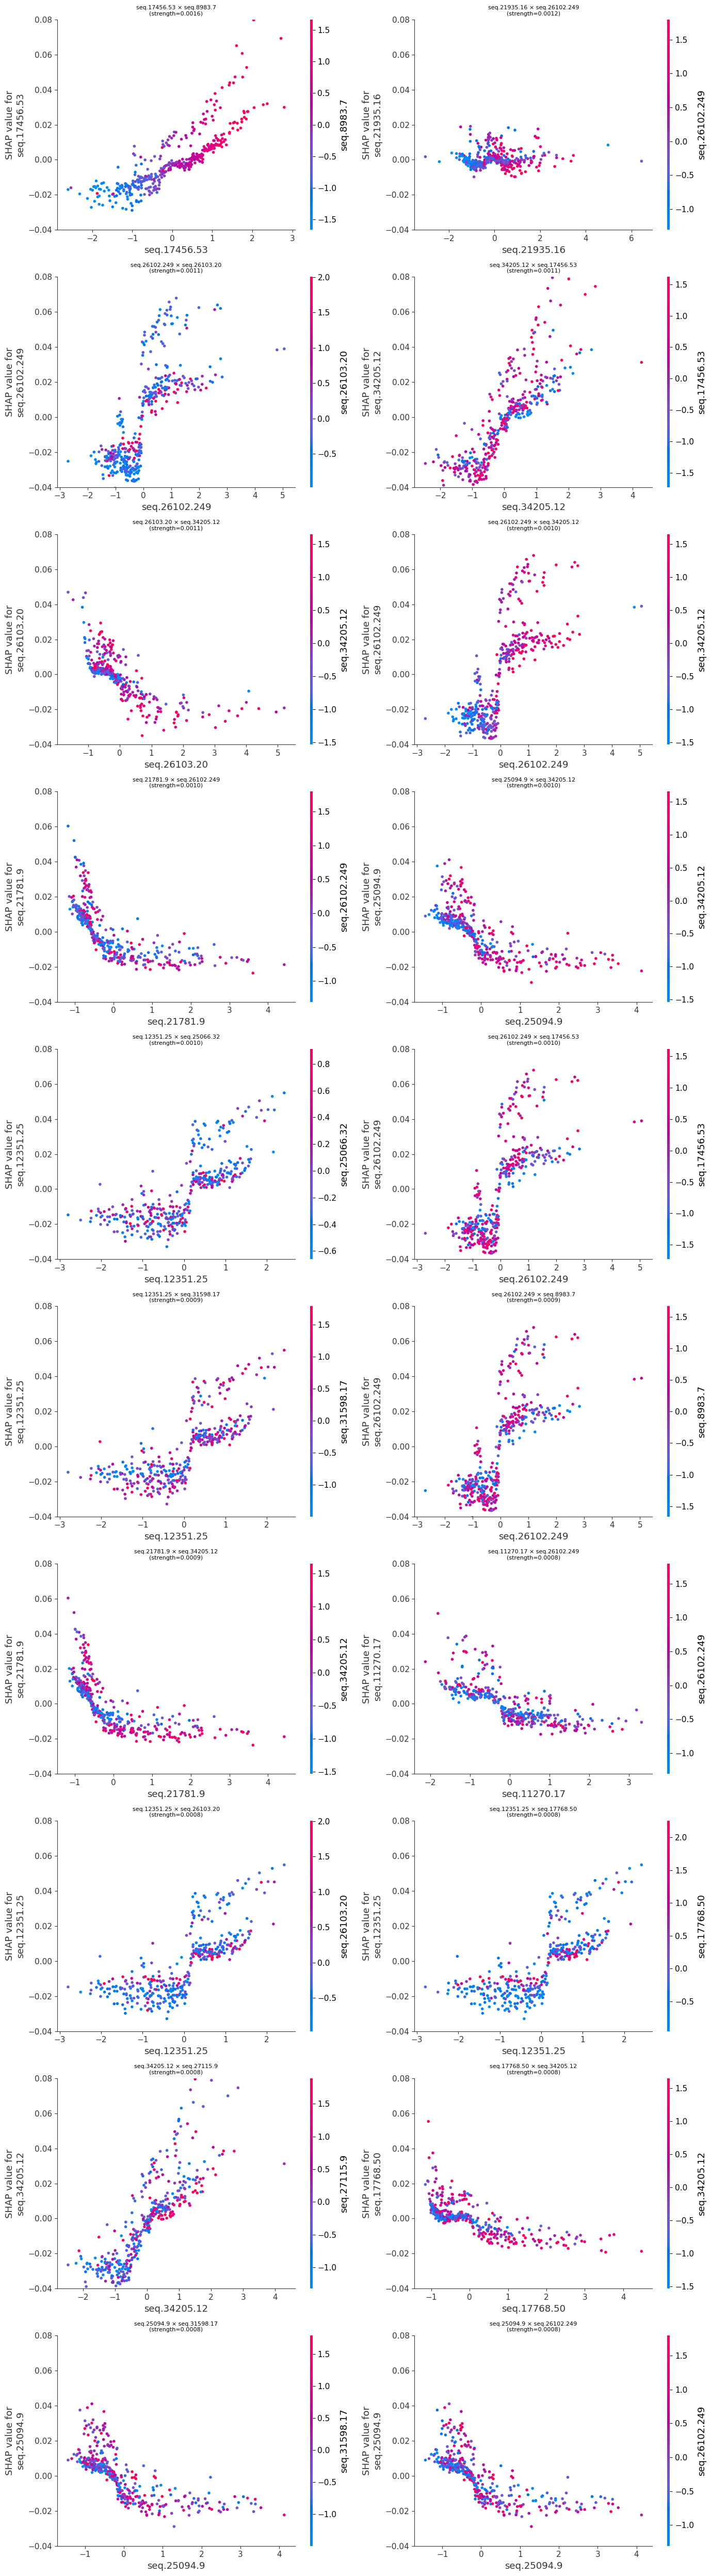

In [ ]:
n_pairs = len(top_interactions_from_shap)
n_cols = 2
n_rows = (n_pairs + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# Universal y-axis limits based on all protein1 SHAP values shown in the plots
plot_features = top_interactions_from_shap["protein1"].unique().tolist()
plot_feature_idx = [X_scaled_5.columns.get_loc(f) for f in plot_features]
y_min = shap_vals[:, plot_feature_idx].min()
y_max = shap_vals[:, plot_feature_idx].max()

y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.01
y_min, y_max = -0.04, 0.08

for idx, row in top_interactions_from_shap.iterrows():
    shap.dependence_plot(
        row["protein1"],
        shap_vals,
        X_scaled_5,
        interaction_index=row["protein2"],
        ax=axes[idx],
        show=False
    )
    axes[idx].set_ylim(y_min, y_max)
    axes[idx].set_title(
        f"{row['protein1']} × {row['protein2']}\n(strength={row['interaction_strength']:.4f})",
        fontsize=8
    )

# hide any unused axes
for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# Lista de proteiner som ingår i många kombinationer från top_interactions_from_shap
# Count how many times each protein appears in the top interactions
protein_interaction_counts = (
    pd.concat([
        top_interactions_from_shap[["protein1", "interaction_strength"]].rename(columns={"protein1": "protein"}),
        top_interactions_from_shap[["protein2", "interaction_strength"]].rename(columns={"protein2": "protein"}),
    ])
    .groupby("protein")
    .agg(
        n_interactions=("interaction_strength", "count"),
        total_strength=("interaction_strength", "sum")
    )
    .sort_values(["n_interactions", "total_strength"], ascending=[False, False])
)
protein_interaction_counts


,n_interactions,total_strength
protein,,
seq.26102.249,8,0.007627
seq.34205.12,7,0.006516
seq.12351.25,4,0.003455
seq.17456.53,3,0.003621
seq.26103.20,3,0.002911
seq.25094.9,3,0.002468
seq.8983.7,2,0.002497
seq.21781.9,2,0.001867
seq.31598.17,2,0.001695


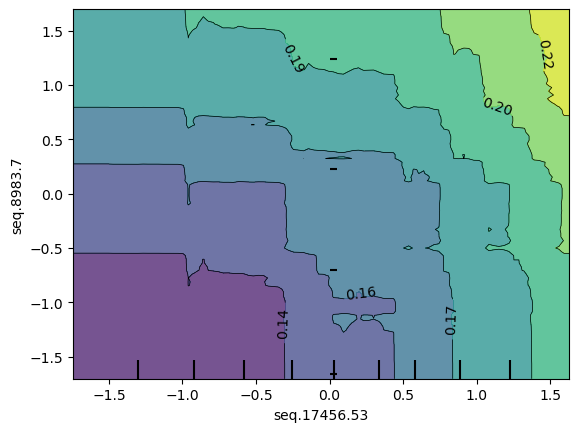

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    rf,
    X_scaled_5,
    [(top_interactions_from_shap['protein1'].iloc[0], top_interactions_from_shap['protein2'].iloc[0])]
)

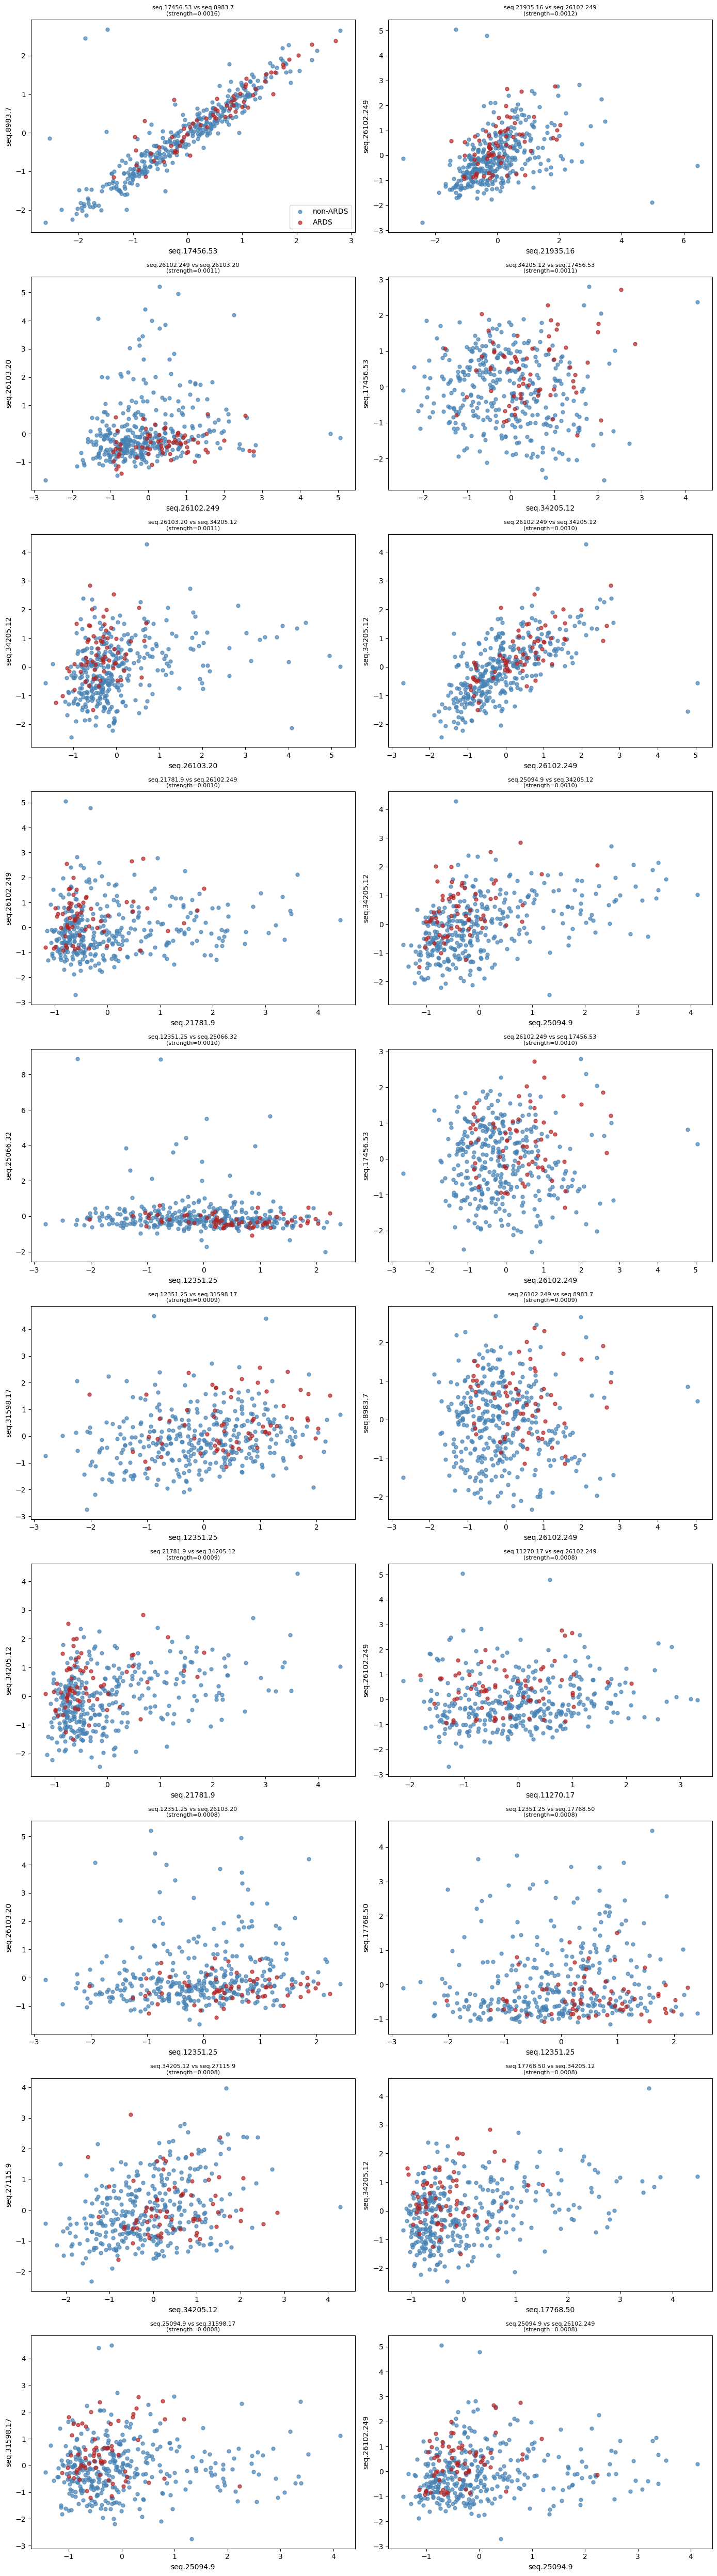

In [ ]:
# scatter plot av alla top interactions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()
for idx, row in top_interactions_from_shap.iterrows():
    p1, p2 = row["protein1"], row["protein2"]
    x = X_scaled_5[p1].to_numpy()
    y = X_scaled_5[p2].to_numpy()

    axes[idx].scatter(x[mask_non_ards], y[mask_non_ards], s=25, alpha=0.7, color="steelblue", label="non-ARDS")
    axes[idx].scatter(x[mask_ards], y[mask_ards], s=25, alpha=0.7, color="firebrick", label="ARDS")

    axes[idx].set_xlabel(p1)
    axes[idx].set_ylabel(p2)
    axes[idx].set_title(f"{p1} vs {p2}\n(strength={row['interaction_strength']:.4f})", fontsize=8)

    if idx == 0:
        axes[idx].legend(title="")
plt.tight_layout()
plt.show()


/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


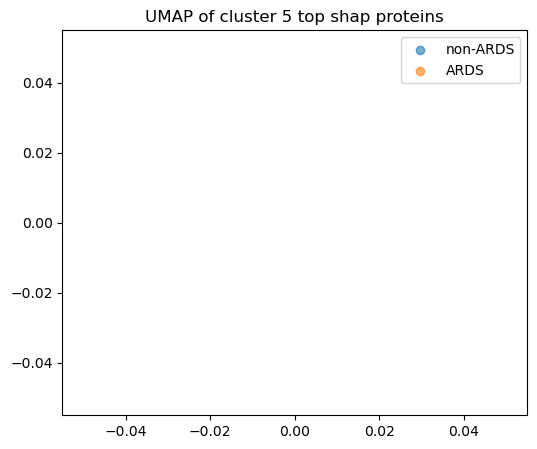

In [ ]:
import umap

X_top_shap = X_scaled_5[shap_importance.head(10).index]

embedding = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
).fit_transform(X_top_shap)

plt.figure(figsize=(6,5))

plt.scatter(
    embedding[y==0,0],
    embedding[y==0,1],
    alpha=0.6,
    label="non-ARDS"
)

plt.scatter(
    embedding[y==1,0],
    embedding[y==1,1],
    alpha=0.6,
    label="ARDS"
)

plt.legend()
plt.title("UMAP of cluster 5 top shap proteins")
plt.show()

# Var ligger top SHAP proteiner i det linjära proteinnätverket?

Top-5 SHAP proteins: ['seq.26102.249', 'seq.34205.12', 'seq.12351.25', 'seq.31598.17', 'seq.8983.7']
Present in G5: ['seq.26102.249', 'seq.34205.12', 'seq.12351.25', 'seq.31598.17', 'seq.8983.7']


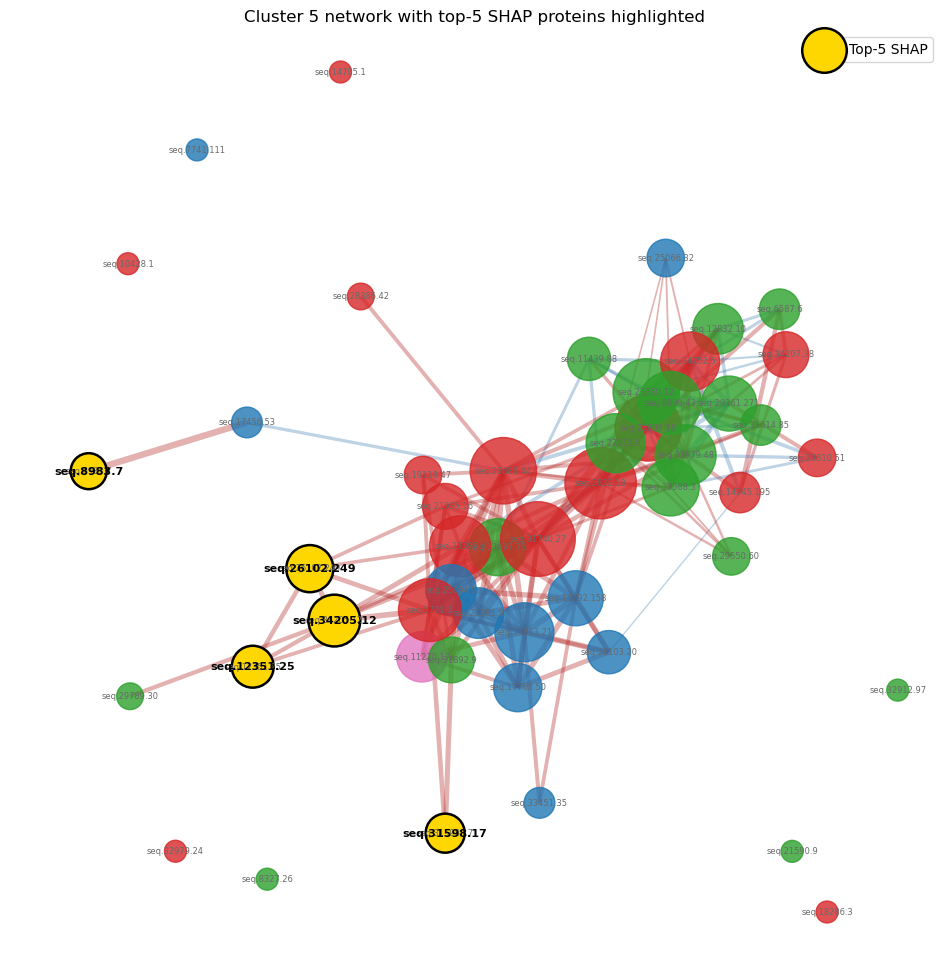

In [ ]:
# Highlight top-5 SHAP proteins in the G5 network

# Top-5 proteins by SHAP importance
top5_shap = shap_importance.head(5).index.tolist()
top5_in_G5 = [p for p in top5_shap if p in G5.nodes()]
missing_in_G5 = [p for p in top5_shap if p not in G5.nodes()]

print("Top-5 SHAP proteins:", top5_shap)
print("Present in G5:", top5_in_G5)
if missing_in_G5:
    print("Not present in G5:", missing_in_G5)

# Base node color by feature-selection method (same style as previous network)
node_colors = [
    color_map.get(G5.nodes[n]["method"], "grey")
    for n in G5.nodes()
]

# Base node size by degree
degree_dict = dict(G5.degree())
node_sizes = [250 + 120 * degree_dict[n] for n in G5.nodes()]

# Edge style (same as previous network)
edge_widths = [
    1 + 4 * d["abs_corr"]
    for _, _, d in G5.edges(data=True)
]
edge_colors = [
    "firebrick" if d["corr"] > 0 else "steelblue"
    for _, _, d in G5.edges(data=True)
]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G5, seed=7, k=0.5)

# Draw full network
nx.draw_networkx_edges(
    G5,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.35
)

nx.draw_networkx_nodes(
    G5,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.8
)

# Overlay highlighted top-5 SHAP nodes
highlight_sizes = [node_sizes[list(G5.nodes()).index(n)] + 300 for n in top5_in_G5]
nx.draw_networkx_nodes(
    G5,
    pos,
    nodelist=top5_in_G5,
    node_color="gold",
    edgecolors="black",
    linewidths=1.8,
    node_size=highlight_sizes,
    alpha=1.0,
    label="Top-5 SHAP"
)

# Label all nodes lightly, then top-5 SHAP nodes clearly
nx.draw_networkx_labels(
    G5,
    pos,
    font_size=6,
    font_color="dimgray"
)

nx.draw_networkx_labels(
    G5,
    pos,
    labels={n: n for n in top5_in_G5},
    font_size=8,
    font_color="black",
    font_weight="bold"
)

plt.title("Cluster 5 network with top-5 SHAP proteins highlighted")
plt.legend(loc="upper right")
plt.axis("off")
plt.show()


Top-5 interaction proteins: ['seq.26102.249', 'seq.34205.12', 'seq.12351.25', 'seq.17456.53', 'seq.26103.20']
Present in G5: ['seq.26102.249', 'seq.34205.12', 'seq.12351.25', 'seq.17456.53', 'seq.26103.20']


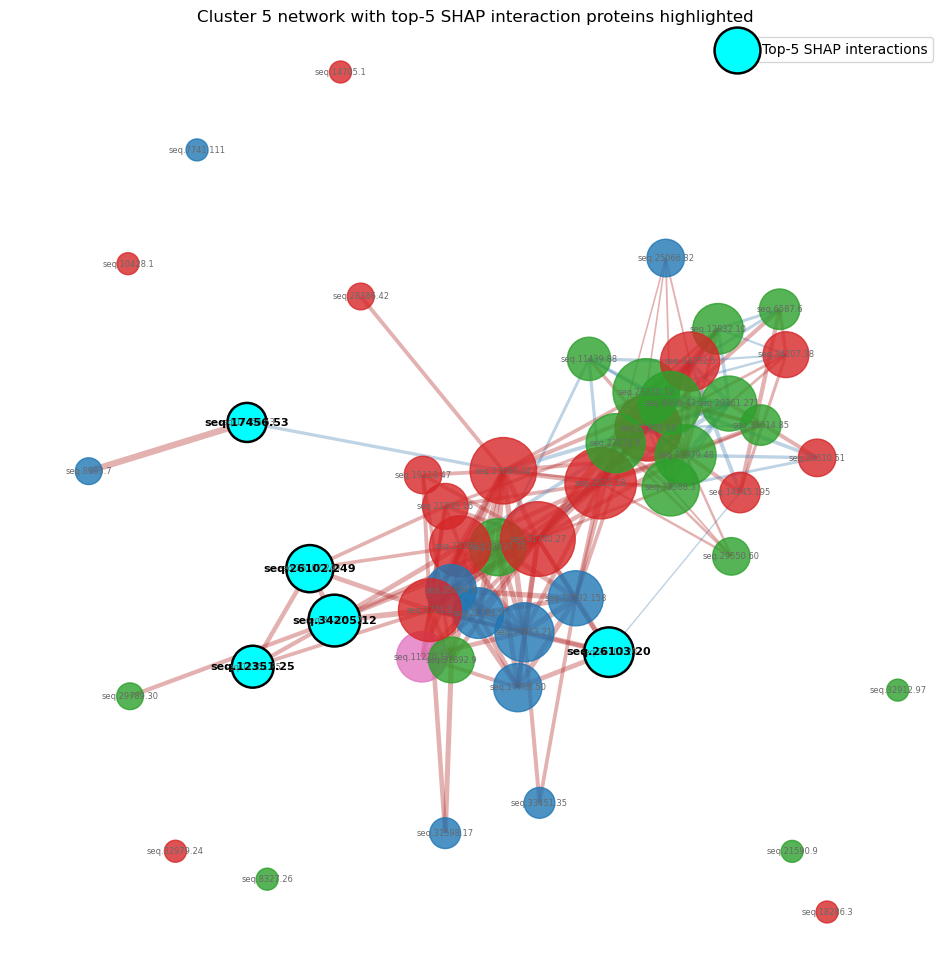

In [ ]:
# Highlight top-5 proteins from SHAP interactions in the G5 network

# Build interaction-based protein ranking if needed
if "protein_interaction_counts" not in globals():
    protein_interaction_counts = (
        pd.concat([
            top_interactions_from_shap[["protein1", "interaction_strength"]].rename(columns={"protein1": "protein"}),
            top_interactions_from_shap[["protein2", "interaction_strength"]].rename(columns={"protein2": "protein"}),
        ])
        .groupby("protein")
        .agg(
            n_interactions=("interaction_strength", "count"),
            total_strength=("interaction_strength", "sum")
        )
        .sort_values(["n_interactions", "total_strength"], ascending=[False, False])
    )

# Top-5 proteins by interaction frequency/strength
top5_interaction_proteins = protein_interaction_counts.head(5).index.tolist()
top5_interaction_in_G5 = [p for p in top5_interaction_proteins if p in G5.nodes()]
missing_in_G5 = [p for p in top5_interaction_proteins if p not in G5.nodes()]

print("Top-5 interaction proteins:", top5_interaction_proteins)
print("Present in G5:", top5_interaction_in_G5)
if missing_in_G5:
    print("Not present in G5:", missing_in_G5)

# Base style (same as previous network)
node_colors = [
    color_map.get(G5.nodes[n]["method"], "grey")
    for n in G5.nodes()
]

degree_dict = dict(G5.degree())
node_sizes = [250 + 120 * degree_dict[n] for n in G5.nodes()]

edge_widths = [
    1 + 4 * d["abs_corr"]
    for _, _, d in G5.edges(data=True)
]
edge_colors = [
    "firebrick" if d["corr"] > 0 else "steelblue"
    for _, _, d in G5.edges(data=True)
]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G5, seed=7, k=0.5)

nx.draw_networkx_edges(
    G5,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.35
)

nx.draw_networkx_nodes(
    G5,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.8
)

# Overlay interaction-based highlighted nodes
node_order = list(G5.nodes())
highlight_sizes = [node_sizes[node_order.index(n)] + 300 for n in top5_interaction_in_G5]
nx.draw_networkx_nodes(
    G5,
    pos,
    nodelist=top5_interaction_in_G5,
    node_color="cyan",
    edgecolors="black",
    linewidths=1.8,
    node_size=highlight_sizes,
    alpha=1.0,
    label="Top-5 SHAP interactions"
)

nx.draw_networkx_labels(
    G5,
    pos,
    font_size=6,
    font_color="dimgray"
)

nx.draw_networkx_labels(
    G5,
    pos,
    labels={n: n for n in top5_interaction_in_G5},
    font_size=8,
    font_color="black",
    font_weight="bold"
)

plt.title("Cluster 5 network with top-5 SHAP interaction proteins highlighted")
plt.legend(loc="upper right")
plt.axis("off")
plt.show()


Top-20 SHAP proteins: 20
Nodes in G5_shap: 20
Edges in G5_shap: 29


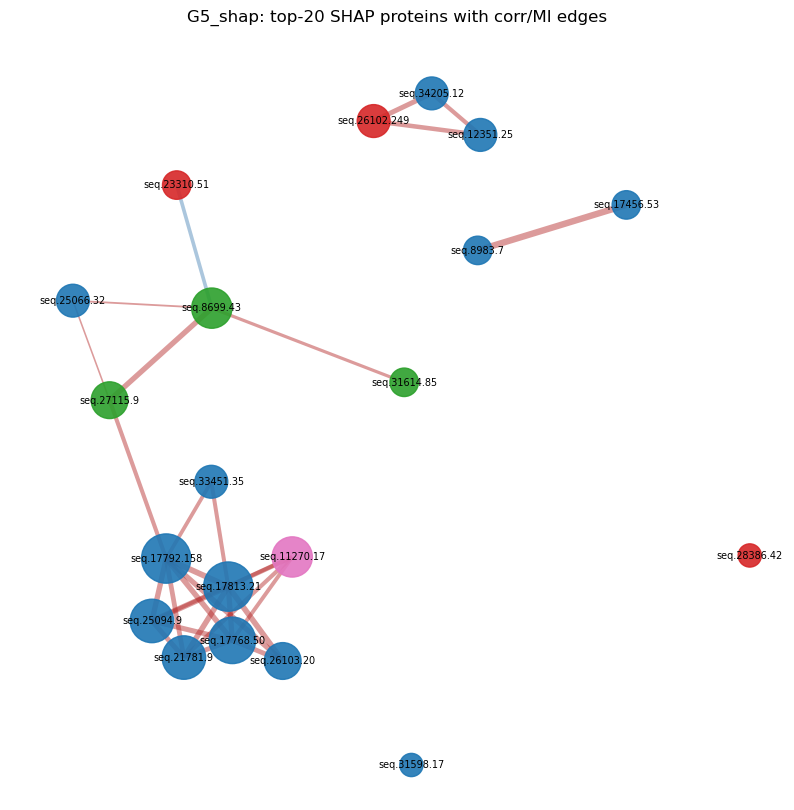

,protein,method,degree
18,seq.17792.158,ttest,7
13,seq.17813.21,ttest,7
16,seq.17768.50,ttest,6
6,seq.21781.9,ttest,5
8,seq.25094.9,ttest,5
10,seq.11270.17,"MI,FS",4
14,seq.8699.43,FS,4
9,seq.26103.20,ttest,3
15,seq.27115.9,FS,3
2,seq.12351.25,ttest,2


In [ ]:
# Build G5_shap: same edge logic as G5, but only top-20 SHAP proteins

top20_shap = shap_importance.head(20).index.tolist()

# Use existing thresholds if available; otherwise recreate them
corr_thr = corr_threshold if "corr_threshold" in globals() else 0.7
mi_thr = mi_threshold if "mi_threshold" in globals() else cluster5_pairs_df["mutual_information"].quantile(0.85)

# Candidate edges among top-20 SHAP proteins only
edges_shap_df = cluster5_pairs_df[
    cluster5_pairs_df["protein1"].isin(top20_shap)
    & cluster5_pairs_df["protein2"].isin(top20_shap)
    & (
        (cluster5_pairs_df["abs_corr"] >= corr_thr)
        | (cluster5_pairs_df["mutual_information"] >= mi_thr)
    )
].copy()

# Build graph
G5_shap = nx.Graph()

for p in top20_shap:
    if p in G5.nodes():
        G5_shap.add_node(p, method=G5.nodes[p].get("method", "unknown"))
    else:
        G5_shap.add_node(p, method="unknown")

for _, row in edges_shap_df.iterrows():
    G5_shap.add_edge(
        row["protein1"],
        row["protein2"],
        corr=row["corr"],
        abs_corr=row["abs_corr"],
        mi=row["mutual_information"]
    )

print("Top-20 SHAP proteins:", len(top20_shap))
print("Nodes in G5_shap:", G5_shap.number_of_nodes())
print("Edges in G5_shap:", G5_shap.number_of_edges())

# Draw network
node_colors_shap = [color_map.get(G5_shap.nodes[n]["method"], "grey") for n in G5_shap.nodes()]
degree_shap = dict(G5_shap.degree())
node_sizes_shap = [280 + 140 * degree_shap[n] for n in G5_shap.nodes()]

edge_widths_shap = [1 + 4 * d["abs_corr"] for _, _, d in G5_shap.edges(data=True)]
edge_colors_shap = ["firebrick" if d["corr"] > 0 else "steelblue" for _, _, d in G5_shap.edges(data=True)]

plt.figure(figsize=(10, 10))
pos_shap = nx.spring_layout(G5_shap, seed=7, k=0.6)

nx.draw_networkx_edges(
    G5_shap,
    pos_shap,
    width=edge_widths_shap,
    edge_color=edge_colors_shap,
    alpha=0.45
)

nx.draw_networkx_nodes(
    G5_shap,
    pos_shap,
    node_color=node_colors_shap,
    node_size=node_sizes_shap,
    alpha=0.9
)

nx.draw_networkx_labels(
    G5_shap,
    pos_shap,
    font_size=7
)

plt.title("G5_shap: top-20 SHAP proteins with corr/MI edges")
plt.axis("off")
plt.show()

# Optional node summary
G5_shap_nodes_df = pd.DataFrame({
    "protein": list(G5_shap.nodes()),
    "method": [G5_shap.nodes[n]["method"] for n in G5_shap.nodes()],
    "degree": [degree_shap[n] for n in G5_shap.nodes()]
}).sort_values(["degree", "protein"], ascending=[False, True])

G5_shap_nodes_df


SHAP interaction threshold (q75): 0.0005
Edges in G5_shap_interact: 24


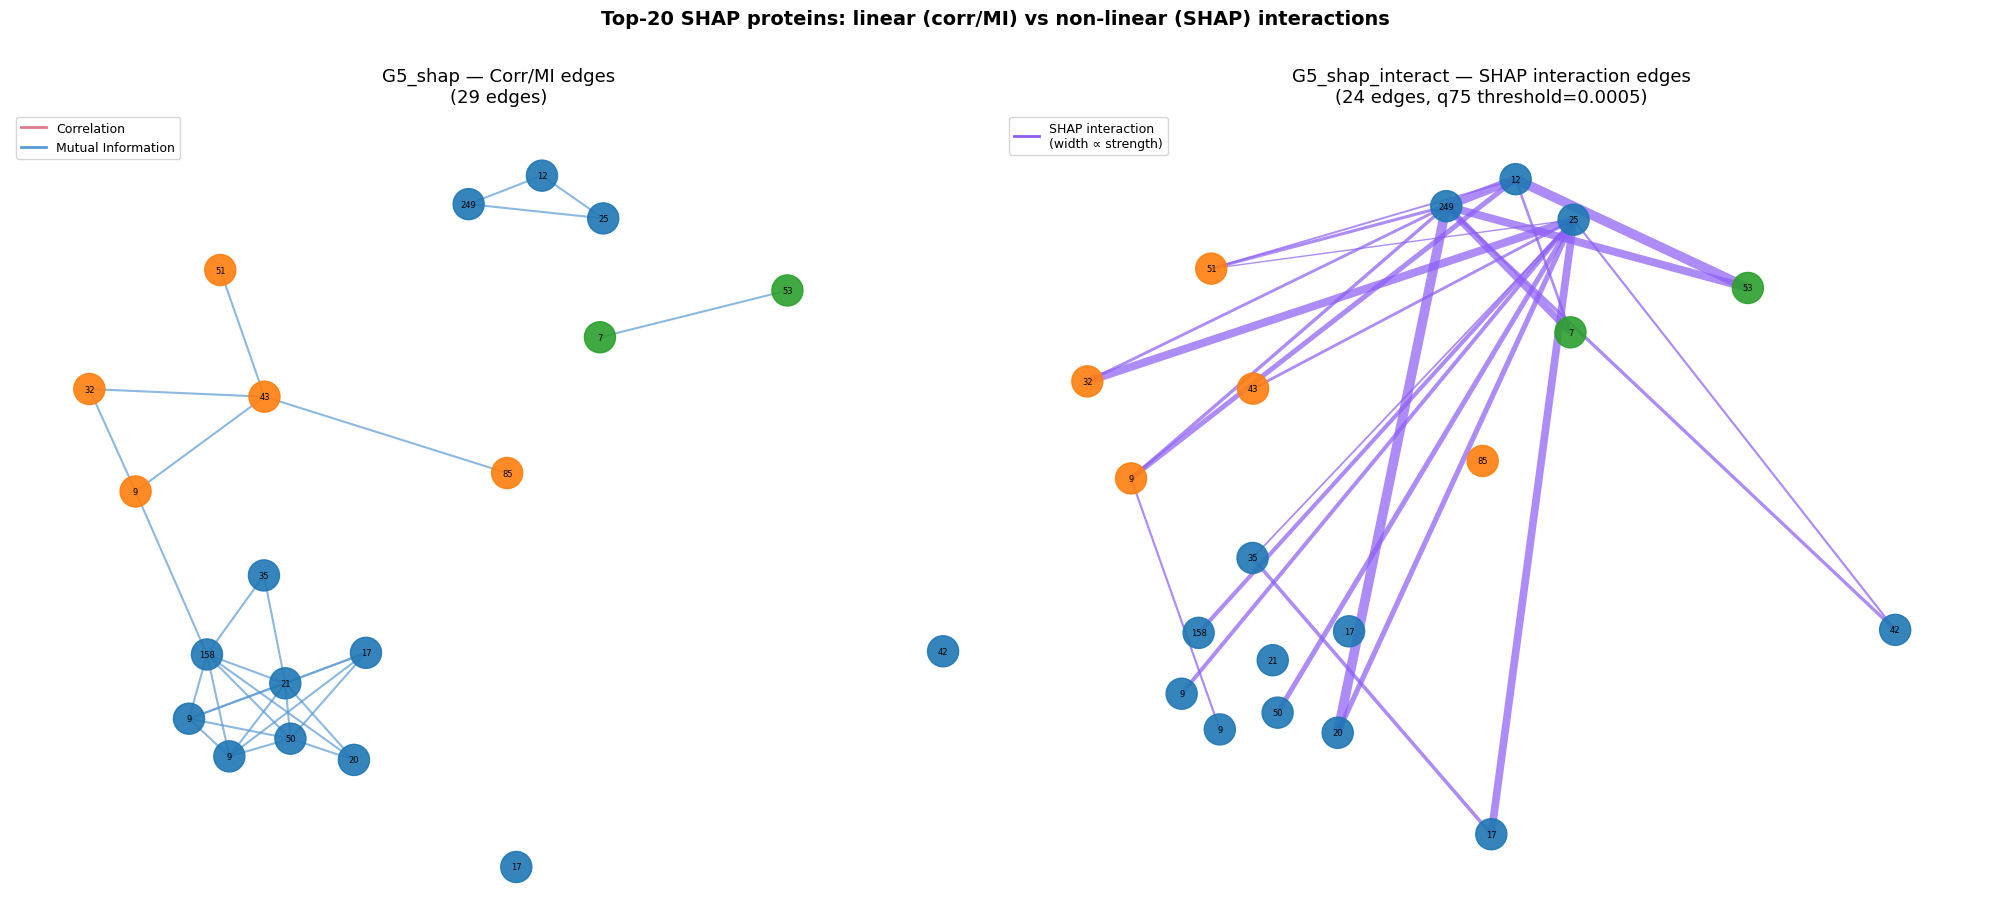


Degree comparison: corr/MI vs SHAP interaction


,shap_importance,degree_corr_mi,degree_shap_int,degree_diff
protein,,,,
seq.12351.25,0.017076,2,10,8
seq.26102.249,0.023848,2,8,6
seq.34205.12,0.020043,2,5,3
seq.27115.9,0.006581,3,3,0
seq.23310.51,0.005937,1,3,2
seq.31598.17,0.014120,0,2,2
seq.8983.7,0.012949,1,2,1
seq.17456.53,0.012514,1,2,1
seq.33451.35,0.011358,2,2,0


In [ ]:
import matplotlib.lines as mlines
# ── G5_shap_interact: edges from SHAP interaction strength ──────────────────

# 1. Filter interaction_df to top-20 SHAP proteins
interact_sub = interaction_df.loc[
    [p for p in top20_shap if p in interaction_df.index],
    [p for p in top20_shap if p in interaction_df.columns]
]

# 2. Stack to long-form (upper triangle only)
interact_long = (
    interact_sub.where(np.triu(np.ones(interact_sub.shape, dtype=bool), k=1))
    .stack()
    .reset_index()
)
interact_long.columns = ["protein1", "protein2", "interaction_strength"]
interact_long = interact_long[interact_long["interaction_strength"] > 0]

# 3. Threshold at 75th percentile
interact_thr = interact_long["interaction_strength"].quantile(0.75)
interact_edges = interact_long[interact_long["interaction_strength"] >= interact_thr].copy()
print(f"SHAP interaction threshold (q75): {interact_thr:.4f}")
print(f"Edges in G5_shap_interact: {len(interact_edges)}")

# 4. Build graph
G5_shap_interact = nx.Graph()
G5_shap_interact.add_nodes_from(top20_shap)
for _, row in interact_edges.iterrows():
    G5_shap_interact.add_edge(row["protein1"], row["protein2"],
                              weight=row["interaction_strength"])

# ── Shared layout (spring on the corr/MI graph for consistency) ──────────────
pos_interact = pos_shap  # reuse same spring layout

# ── Community colours for nodes ──────────────────────────────────────────────
node_comm_colors = [community_palette.get(protein_to_community.get(n, -1), "grey")
                    for n in top20_shap]

# ── Edge attributes for G5_shap ──────────────────────────────────────────────
ec_left, ew_left = [], []
for u, v, d in G5_shap.edges(data=True):
    ec_left.append("#e07b8a" if d.get("type") == "corr" else "#5b9bd5")
    ew_left.append(1.5)

# ── Edge attributes for G5_shap_interact ─────────────────────────────────────
strengths = np.array([d["weight"] for _, _, d in G5_shap_interact.edges(data=True)])
ew_right = 1 + 6 * (strengths - strengths.min()) / (strengths.ptp() + 1e-12)
ec_right = ["#8b5cf6"] * len(strengths)   # purple for SHAP interactions

# ── Plot side-by-side ─────────────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, 9))

# Left: corr/MI network
nx.draw_networkx_edges(G5_shap, pos_interact, ax=ax_l,
                       edge_color=ec_left, width=ew_left, alpha=0.7)
nx.draw_networkx_nodes(G5_shap, pos_interact, ax=ax_l,
                       node_color=node_comm_colors, node_size=500, alpha=0.9)
nx.draw_networkx_labels(G5_shap, pos_interact, ax=ax_l,
                        labels={n: n.split(".")[-1] for n in top20_shap},
                        font_size=6)
ax_l.set_title(f"G5_shap — Corr/MI edges\n({G5_shap.number_of_edges()} edges)", fontsize=13)
ax_l.axis("off")
corr_patch = mlines.Line2D([], [], color="#e07b8a", linewidth=2, label="Correlation")
mi_patch   = mlines.Line2D([], [], color="#5b9bd5", linewidth=2, label="Mutual Information")
ax_l.legend(handles=[corr_patch, mi_patch], loc="upper left", fontsize=9)

# Right: SHAP interaction network
nx.draw_networkx_edges(G5_shap_interact, pos_interact, ax=ax_r,
                       edge_color=ec_right, width=ew_right, alpha=0.7)
nx.draw_networkx_nodes(G5_shap_interact, pos_interact, ax=ax_r,
                       node_color=node_comm_colors, node_size=500, alpha=0.9)
nx.draw_networkx_labels(G5_shap_interact, pos_interact, ax=ax_r,
                        labels={n: n.split(".")[-1] for n in top20_shap},
                        font_size=6)
ax_r.set_title(f"G5_shap_interact — SHAP interaction edges\n({G5_shap_interact.number_of_edges()} edges, q75 threshold={interact_thr:.4f})", fontsize=13)
ax_r.axis("off")
shap_patch = mlines.Line2D([], [], color="#8b5cf6", linewidth=2, label="SHAP interaction\n(width ∝ strength)")
ax_r.legend(handles=[shap_patch], loc="upper left", fontsize=9)

plt.suptitle("Top-20 SHAP proteins: linear (corr/MI) vs non-linear (SHAP) interactions",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Degree comparison table ───────────────────────────────────────────────────
degree_corr_mi   = dict(G5_shap.degree())
degree_shap_int  = dict(G5_shap_interact.degree())

G5_shap_interact_nodes_df = pd.DataFrame({
    "protein":           top20_shap,
    "shap_importance":   [shap_importance[p] for p in top20_shap],
    "degree_corr_mi":    [degree_corr_mi.get(p, 0)  for p in top20_shap],
    "degree_shap_int":   [degree_shap_int.get(p, 0) for p in top20_shap],
}).set_index("protein")

G5_shap_interact_nodes_df["degree_diff"] = (
    G5_shap_interact_nodes_df["degree_shap_int"] -
    G5_shap_interact_nodes_df["degree_corr_mi"]
)
G5_shap_interact_nodes_df = G5_shap_interact_nodes_df.sort_values("degree_shap_int", ascending=False)
print("\nDegree comparison: corr/MI vs SHAP interaction")
display(G5_shap_interact_nodes_df)


In [ ]:
print(shap_importance.head(5))

seq.26102.249    0.023848
seq.34205.12     0.020043
seq.12351.25     0.017076
seq.31598.17     0.014120
seq.8983.7       0.012949
dtype: float64


In [ ]:
print(type(shap_importance))
print(np.shape(shap_importance))
print(type(shap_importance[0]))
print(shap_importance[:5])
print(shap_importance[0])

<class 'pandas.core.series.Series'>
(42,)
<class 'numpy.float64'>
seq.26102.249    0.023848
seq.34205.12     0.020043
seq.12351.25     0.017076
seq.31598.17     0.014120
seq.8983.7       0.012949
dtype: float64
0.023847951960739123


/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_20039/1528626057.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(type(shap_importance[0]))
/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_20039/1528626057.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(shap_importance[0])


In [ ]:
import pandas as pd
import re

ANNOT_PATH = "../somalogic_annotation.csv"

def protein_to_probeid(name: str) -> str:
    s = str(name)
    s = re.sub(r"^seq\.", "", s)
    s = re.sub(r"^seq", "", s)
    s = re.sub(r"([0-9]+)\.([0-9]+)", r"\1-\2", s)
    return s

# Gör Series -> DataFrame
shap_df = shap_importance.rename_axis("Protein").reset_index(name="SHAP")

# Skapa PROBEID från Protein-kolumnen
shap_df["PROBEID"] = shap_df["Protein"].map(protein_to_probeid)

# Läs annotation
annot = pd.read_csv(ANNOT_PATH)

for col in ["PROBEID", "SYMBOL", "UNIPROT", "GENENAME"]:
    if col in annot.columns:
        annot[col] = annot[col].astype(str).replace({"nan": ""})

# Merge med annotation
shap_df = shap_df.merge(
    annot[["PROBEID", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="PROBEID",
    how="left"
)

# Kolla resultat
print(shap_df[["Protein", "SHAP", "PROBEID", "SYMBOL"]].head(10))

         Protein      SHAP    PROBEID  SYMBOL
0  seq.26102.249  0.023848  26102-249     DUT
1   seq.34205.12  0.020043   34205-12  PABPC1
2   seq.12351.25  0.017076   12351-25   STAT1
3   seq.31598.17  0.014120   31598-17    MAFF
4     seq.8983.7  0.012949     8983-7   GOLM1
5   seq.17456.53  0.012514   17456-53   GOLM1
6    seq.21781.9  0.011950    21781-9    ACY3
7   seq.33451.35  0.011358   33451-35    HSF4
8    seq.25094.9  0.010702    25094-9   ACSS2
9   seq.26103.20  0.009510   26103-20  SDHAF2


In [ ]:
print(shap_df[["Protein", "SHAP", "PROBEID", "SYMBOL"]])


          Protein      SHAP    PROBEID     SYMBOL
0   seq.26102.249  0.023848  26102-249        DUT
1    seq.34205.12  0.020043   34205-12     PABPC1
2    seq.12351.25  0.017076   12351-25      STAT1
3    seq.31598.17  0.014120   31598-17       MAFF
4      seq.8983.7  0.012949     8983-7      GOLM1
5    seq.17456.53  0.012514   17456-53      GOLM1
6     seq.21781.9  0.011950    21781-9       ACY3
7    seq.33451.35  0.011358   33451-35       HSF4
8     seq.25094.9  0.010702    25094-9      ACSS2
9    seq.26103.20  0.009510   26103-20     SDHAF2
10   seq.11270.17  0.009133   11270-17    CHCHD10
11   seq.25066.32  0.007968   25066-32       GYG2
12   seq.28386.42  0.007836   28386-42      PEX5L
13   seq.17813.21  0.007129   17813-21       BPHL
14    seq.8699.43  0.006949    8699-43      CRIM1
15    seq.27115.9  0.006581    27115-9       ORM2
16   seq.17768.50  0.006334   17768-50       HAO1
17   seq.23310.51  0.005937   23310-51      RAB38
18  seq.17792.158  0.005663  17792-158    ALDH5A1


# Permutationstest av 3 viktigaste shap proteinerna för att se signifikans

Running 100 permutations (RF n_estimators=100)…
  25/100 done
  50/100 done
  75/100 done
  100/100 done
Permutations complete.


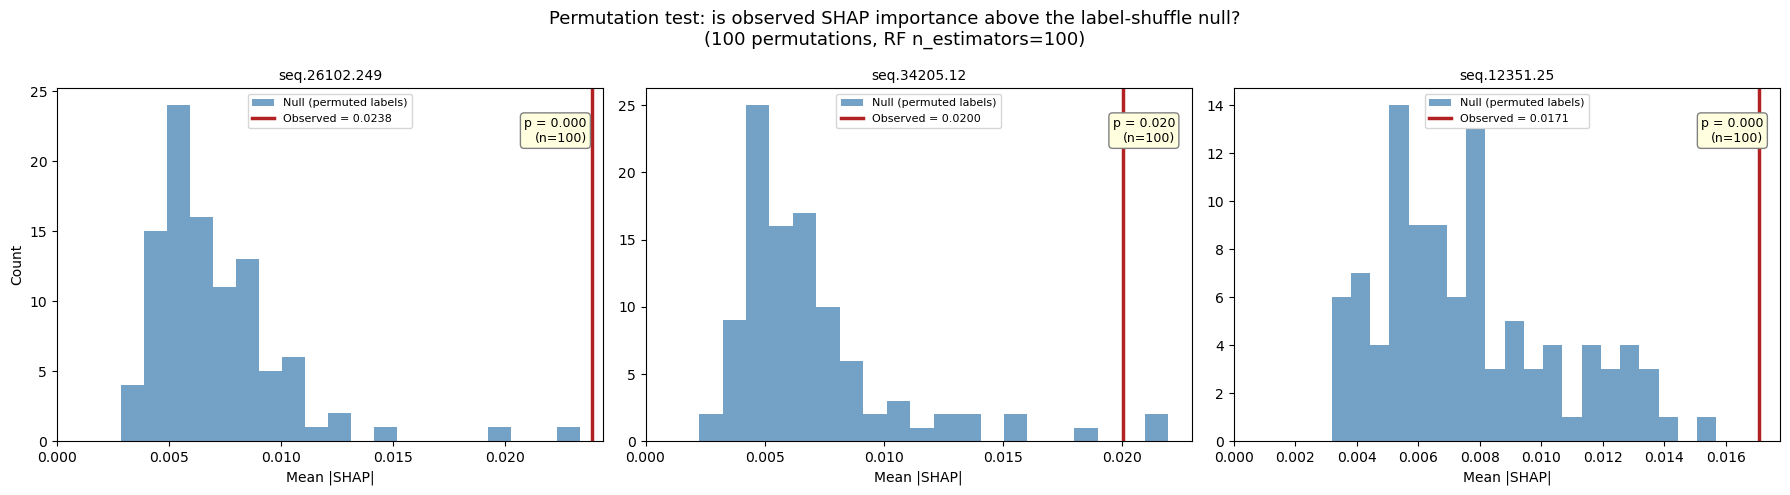

,observed_shap,null_mean,null_std,p_value,signal_to_noise
protein,,,,,
seq.26102.249,0.02385,0.00710,0.00304,0.00,3.36045
seq.34205.12,0.02004,0.00699,0.00352,0.02,2.86721
seq.12351.25,0.01708,0.00764,0.00289,0.00,2.23550


In [ ]:
# ── Permutation test: label-shuffle null distribution for top-3 SHAP proteins ──
#
# Procedure (per protein):
#   1. Record the observed mean |SHAP| from the original model.
#   2. Repeatedly shuffle the ARDS labels, refit an RF, recompute SHAP,
#      and record the null mean |SHAP| for that protein.
#   3. p-value = fraction of null values >= observed.
#
# Note: permutation RF uses n_estimators=100 (vs 500 in the original model)
# to keep runtime reasonable (~1-2 min total for 100 permutations × 3 proteins).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier

N_PERMS = 100
N_ESTIMATORS_PERM = 100  # lighter model for null distribution

top3_proteins = shap_importance.head(3).index.tolist()

# Observed importances from the already-computed full model
observed = {p: shap_importance[p] for p in top3_proteins}

# Robust binary label vector
label_candidates = {
    "y_true": globals().get("y_true", None),
    "ards_label": globals().get("ards_label", None),
}
y_bin = None
for _, cand in label_candidates.items():
    if cand is None:
        continue
    s = pd.Series(np.asarray(cand).ravel())
    if pd.unique(s.dropna()).size == 2:
        y_bin = s.to_numpy().astype(int)
        break
if y_bin is None:
    raise ValueError("No binary label vector found.")

X_arr = X_scaled_5.to_numpy()
feat_names = X_scaled_5.columns.tolist()
feat_idx = {p: feat_names.index(p) for p in top3_proteins}

rng = np.random.default_rng(42)

# Storage: dict protein -> list of null importances
null_distributions = {p: [] for p in top3_proteins}

print(f"Running {N_PERMS} permutations (RF n_estimators={N_ESTIMATORS_PERM})…")
for perm in range(N_PERMS):
    y_perm = rng.permutation(y_bin)

    rf_perm = RandomForestClassifier(
        n_estimators=N_ESTIMATORS_PERM,
        random_state=perm,
        n_jobs=-1,
    )
    rf_perm.fit(X_arr, y_perm)

    exp_perm = shap.TreeExplainer(rf_perm)
    sv_perm = exp_perm.shap_values(X_arr)

    # Version-safe class-1 extraction
    if isinstance(sv_perm, list):
        sv1 = sv_perm[1]
    elif isinstance(sv_perm, np.ndarray) and sv_perm.ndim == 3:
        sv1 = sv_perm[:, :, 1]
    else:
        sv1 = sv_perm

    for p in top3_proteins:
        null_distributions[p].append(np.abs(sv1[:, feat_idx[p]]).mean())

    if (perm + 1) % 25 == 0:
        print(f"  {perm + 1}/{N_PERMS} done")

print("Permutations complete.")

# ── Plot results ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

perm_summary = []
for i, p in enumerate(top3_proteins):
    ax = axes[i]
    null = np.array(null_distributions[p])
    obs  = observed[p]
    pval = (null >= obs).mean()

    ax.hist(null, bins=20, color="steelblue", alpha=0.75, label="Null (permuted labels)")
    ax.axvline(obs, color="firebrick", linewidth=2.5, label=f"Observed = {obs:.4f}")
    ax.set_title(p, fontsize=10)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_ylabel("Count" if i == 0 else "")
    ax.legend(fontsize=8)
    ax.set_xlim(left=0)

    # Annotate p-value
    ymax = ax.get_ylim()[1]
    ax.text(
        0.97, 0.92,
        f"p = {pval:.3f}\n(n={N_PERMS})",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="grey"),
    )

    perm_summary.append({"protein": p, "observed_shap": obs,
                          "null_mean": null.mean(), "null_std": null.std(),
                          "p_value": pval})

fig.suptitle(
    "Permutation test: is observed SHAP importance above the label-shuffle null?\n"
    f"({N_PERMS} permutations, RF n_estimators={N_ESTIMATORS_PERM})",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
perm_df = pd.DataFrame(perm_summary).set_index("protein")
perm_df["signal_to_noise"] = perm_df["observed_shap"] / (perm_df["null_mean"] + 1e-12)
display(perm_df.round(5))

# Cluster scriptet

In [4]:
import sys
sys.path.append("../scripts")

from cluster import (run_pipeline, load_data, preprocess,
                     threshold_sensitivity, hierarchical_clustering)

In [2]:
# Cell 2: välj threshold innan du kör hela pipeline
X, y = load_data("../data/processed/filtered_data_top60.csv")
X = preprocess(X)
threshold_sensitivity(X, y, thresholds=[0.5, 0.6, 0.7, 0.8])

threshold=0.5  →  31 clusters, 114 edges, 25 isolated, modularity=0.365
threshold=0.6  →  40 clusters, 59 edges, 34 isolated, modularity=0.399
threshold=0.7  →  45 clusters, 20 edges, 40 isolated, modularity=0.519
threshold=0.8  →  58 clusters, 1 edges, 57 isolated, modularity=0.000


,threshold,n_clusters,n_edges,n_isolated,modularity
0,0.5,31,114,25,0.365
1,0.6,40,59,34,0.399
2,0.7,45,20,40,0.519
3,0.8,58,1,57,0.000


In [6]:
# Cell 2: välj threshold — kör detta först och inspektera resultatet
X, y = load_data("../data/processed/filtered_data_top60.csv")
X = preprocess(X)
threshold_sensitivity(X, y, thresholds=[0.3, 0.35, 0.4, 0.45, 0.5])

threshold=0.3  →  17 clusters, 368 edges, 14 isolated, modularity=0.321
threshold=0.35  →  18 clusters, 284 edges, 15 isolated, modularity=0.319
threshold=0.4  →  23 clusters, 213 edges, 19 isolated, modularity=0.308
threshold=0.45  →  27 clusters, 145 edges, 23 isolated, modularity=0.356
threshold=0.5  →  31 clusters, 114 edges, 25 isolated, modularity=0.365


,threshold,n_clusters,n_edges,n_isolated,modularity
0,0.30,17,368,14,0.321
1,0.35,18,284,15,0.319
2,0.40,23,213,19,0.308
3,0.45,27,145,23,0.356
4,0.50,31,114,25,0.365


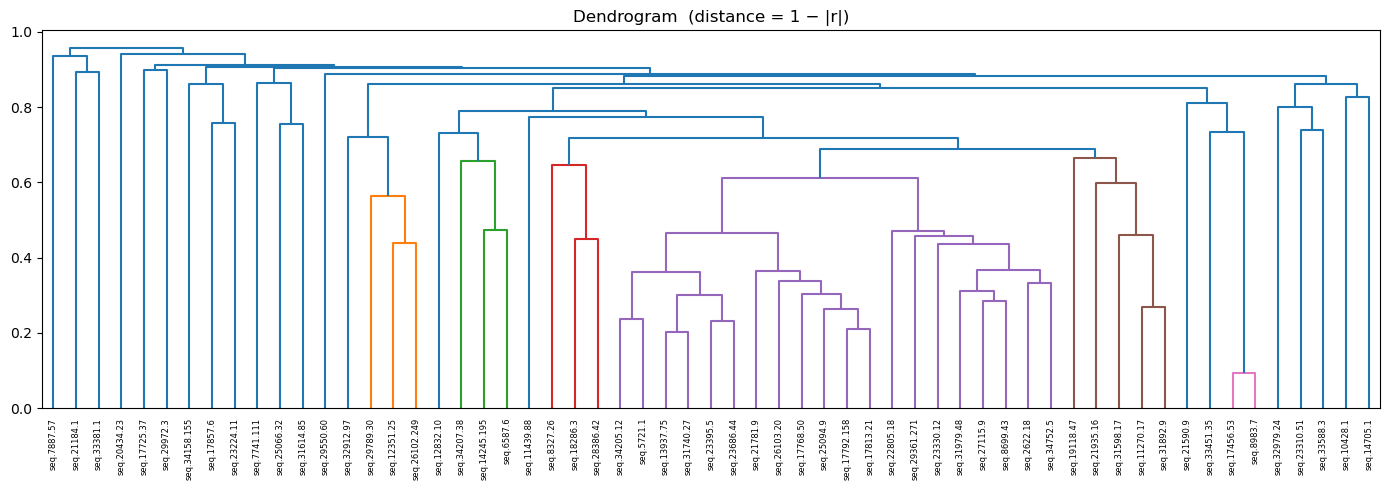

Series([], dtype: int64)

In [8]:
# Cell 3: inspektera dendrogram för att se naturliga klustergränser
hierarchical_clustering(X.corr(), n_clusters=None)

Running permutation tests for 140 candidate pairs (1000 permutations each)...
Done. 102/140 pairs significant at FDR=0.05.


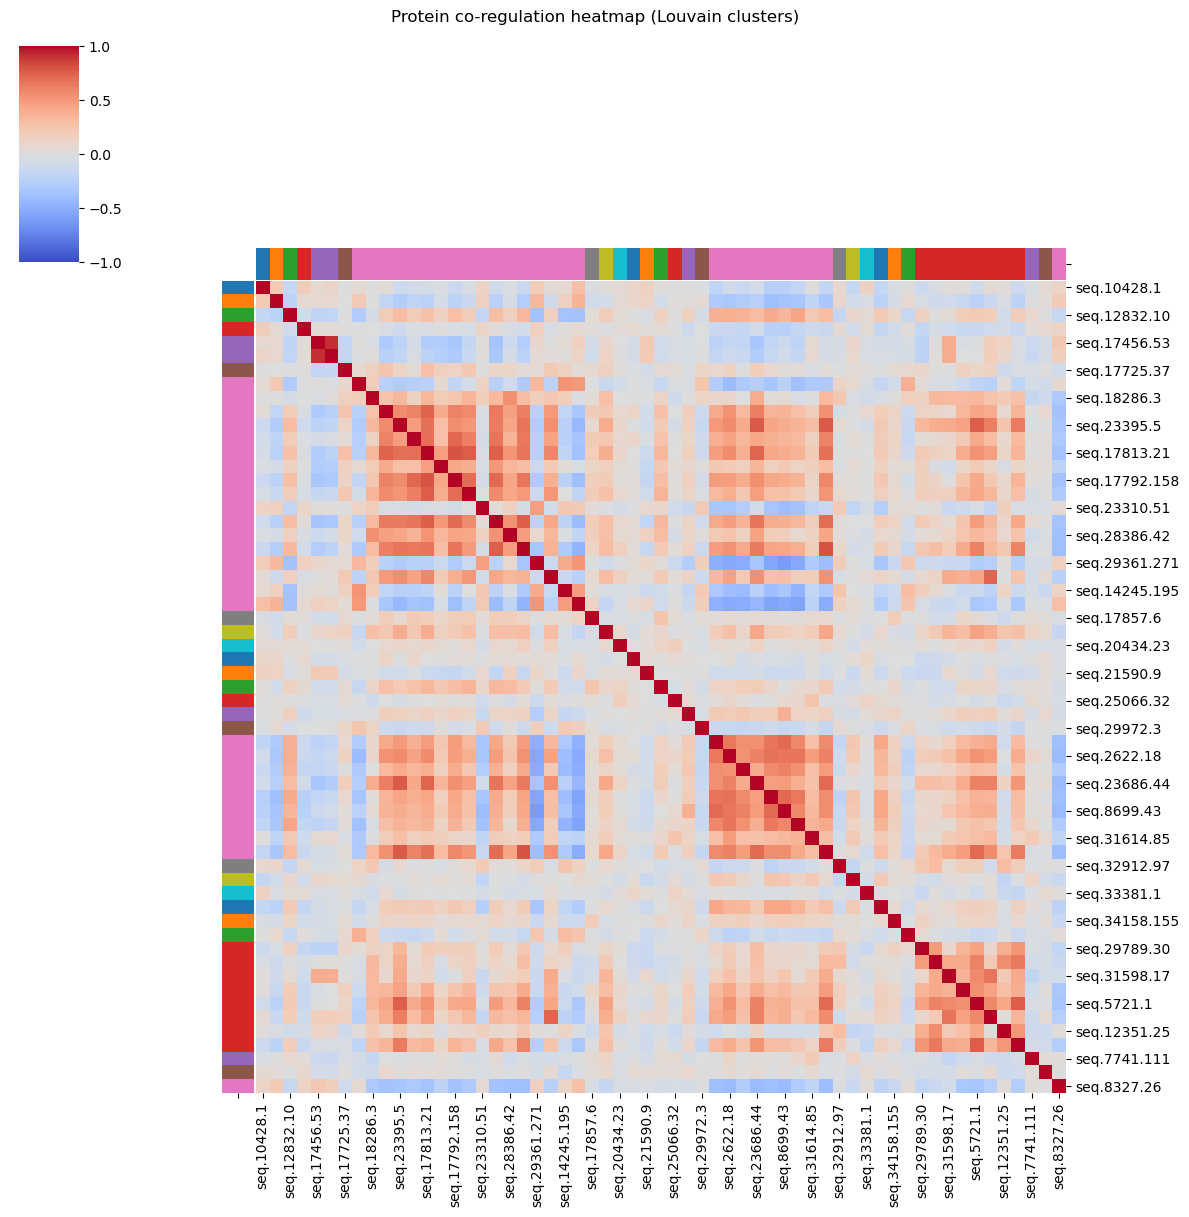

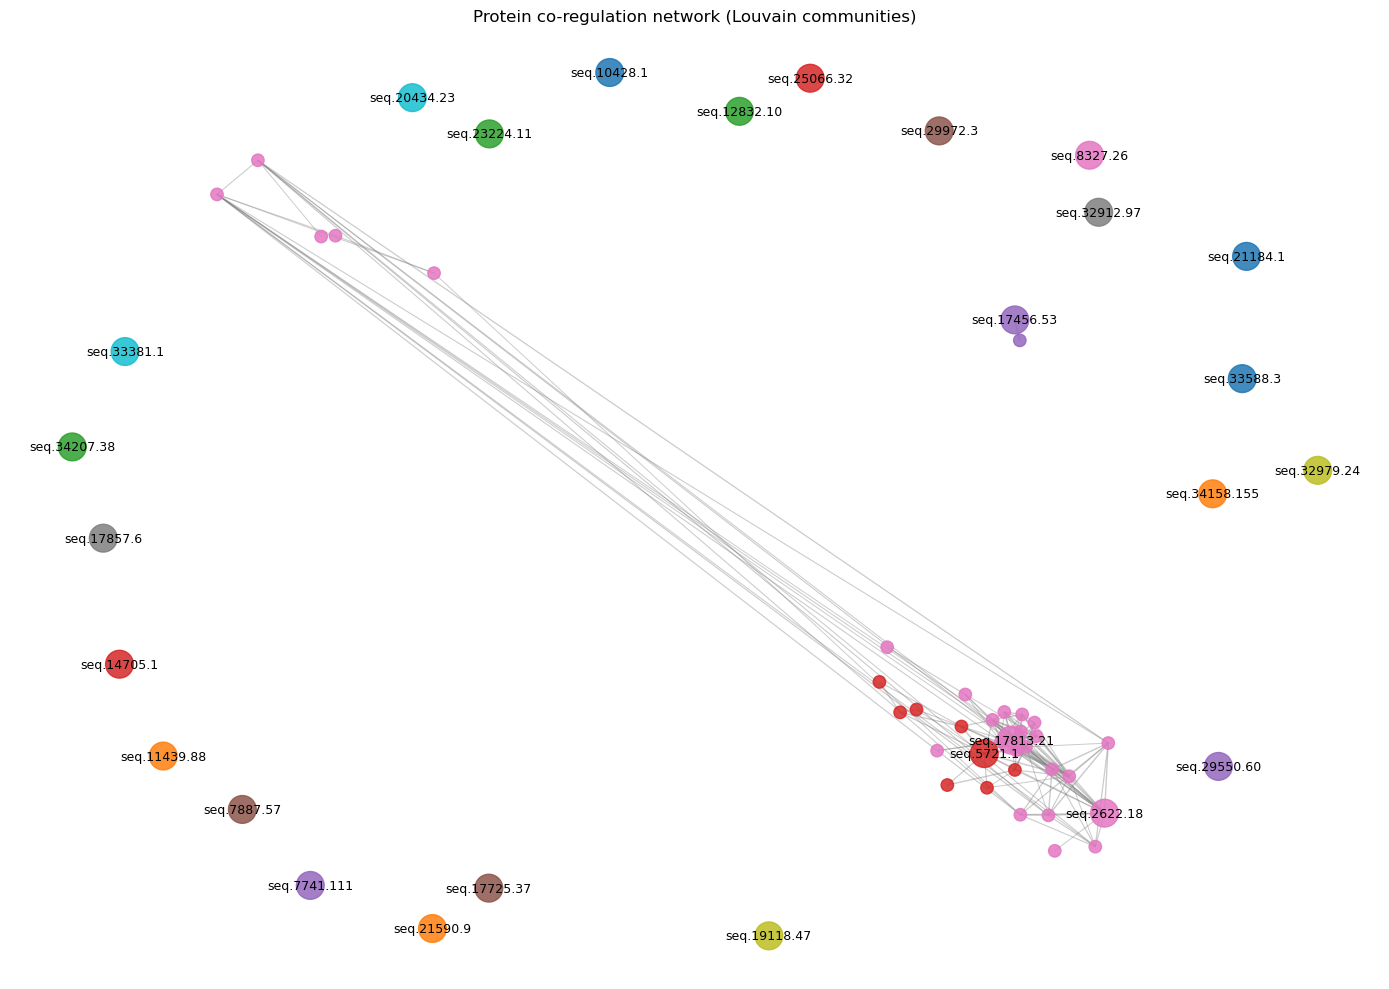

In [9]:
# Cell 4: kör hela pipeline med valt threshold
# Justera threshold baserat på vad cell 2 och 3 visade
results = run_pipeline(
    data="../data/processed/filtered_data_top60.csv",
    label_col="ards",
    corr_method="pearson",
    threshold=0.45,        # ← justera detta baserat på cell 2
    rep_method="connectivity",
    aggregation="zscore_mean",
    n_perm=1000,
    diff_threshold=0.3,
    fdr_alpha=0.05,
    plot=True,
)

In [10]:
# Cell 5: inspektera klusterassignments
cluster_df = results["cluster_assignments"].reset_index()
cluster_df.columns = ["protein", "cluster"]
print(f"Antal kluster: {cluster_df['cluster'].nunique()}")
print(f"Proteiner per kluster:")
print(cluster_df.groupby("cluster")["protein"].apply(list))

Antal kluster: 27
Proteiner per kluster:
cluster
0                                         [seq.10428.1]
1                                        [seq.11439.88]
2                                        [seq.12832.10]
3                                         [seq.14705.1]
4                            [seq.17456.53, seq.8983.7]
5                                        [seq.17725.37]
6     [seq.14245.195, seq.11270.17, seq.29361.271, s...
7                                         [seq.17857.6]
8                                        [seq.19118.47]
9                                        [seq.20434.23]
10                                        [seq.21184.1]
11                                        [seq.21590.9]
12                                       [seq.23224.11]
13                                       [seq.25066.32]
14                                       [seq.29550.60]
15                                        [seq.29972.3]
16    [seq.27115.9, seq.2622.18, seq.23330.12, seq.2...

In [12]:
import pandas as pd
# Cell 6: inspektera representativa proteiner
reps = results["representatives"]
rep_df = pd.Series(reps, name="representative").reset_index()
rep_df.columns = ["cluster", "representative"]
print(rep_df)

    cluster representative
0         0    seq.10428.1
1         1   seq.11439.88
2         2   seq.12832.10
3         3    seq.14705.1
4         4   seq.17456.53
5         5   seq.17725.37
6         6   seq.17813.21
7         7    seq.17857.6
8         8   seq.19118.47
9         9   seq.20434.23
10       10    seq.21184.1
11       11    seq.21590.9
12       12   seq.23224.11
13       13   seq.25066.32
14       14   seq.29550.60
15       15    seq.29972.3
16       16    seq.2622.18
17       17   seq.32912.97
18       18   seq.32979.24
19       19    seq.33381.1
20       20    seq.33588.3
21       21  seq.34158.155
22       22   seq.34207.38
23       23     seq.5721.1
24       24   seq.7741.111
25       25    seq.7887.57
26       26    seq.8327.26


In [13]:
# Cell 7: inspektera meta-proteiner
meta = results["meta_proteins"]
print(f"Shape: {meta.shape}")
print(meta.head())

Shape: (408, 27)
     meta_0    meta_1    meta_2    meta_3    meta_4    meta_5    meta_6  \
0  1.388627 -0.446986 -0.550369  0.797439 -0.320701 -0.325330 -0.513032   
1 -0.795224 -0.848644  0.570379 -0.331008 -1.347505 -0.757586 -0.575345   
2 -0.649354 -1.036503  0.902966 -0.235079 -1.754110 -0.205381  1.055276   
3  0.320946  0.107437  0.282863  0.002452 -0.460509 -0.274178  0.187899   
4 -0.239004 -0.246546 -0.749908 -0.361023 -1.538721 -0.392907 -0.018857   

     meta_7    meta_8    meta_9  ...   meta_17   meta_18   meta_19   meta_20  \
0 -0.233889 -0.924202 -0.577469  ... -0.051151 -0.426770  1.312475 -0.070536   
1 -0.543590 -0.527430 -0.061124  ... -0.252701 -1.562159 -0.150239 -0.671325   
2  1.084257  0.317695  0.478513  ...  0.044062 -0.915562 -0.653247 -0.286529   
3 -0.055078  0.038152 -0.500149  ...  0.269665 -0.389741 -0.648823 -0.701174   
4  0.119334 -0.212594 -0.080885  ... -0.713996  0.150541 -0.635588  0.060905   

    meta_21   meta_22   meta_23   meta_24   meta_25

In [14]:
# Cell 8: inspektera permutationstestresultat
perm = results["perm_results"]
if len(perm) > 0:
    print(f"Totalt testade par: {len(perm)}")
    print(f"Signifikanta par (FDR < 0.05): {perm['significant'].sum()}")
    print("\nTop 10 mest signifikanta par:")
    print(perm.head(10))
else:
    print("Inga signifikanta par hittades — prova sänka diff_threshold.")

Totalt testade par: 140
Signifikanta par (FDR < 0.05): 102

Top 10 mest signifikanta par:
       protein_1     protein_2  obs_diff  p_value  p_adjusted  significant
0   seq.12832.10  seq.25066.32  0.453470    0.000    0.000000         True
1    seq.33588.3    seq.6587.6  0.445549    0.000    0.000000         True
2   seq.17768.50  seq.17813.21 -0.348854    0.000    0.000000         True
3   seq.12832.10  seq.26103.20 -0.413264    0.000    0.000000         True
4    seq.25094.9   seq.27115.9 -0.453699    0.000    0.000000         True
5   seq.17768.50  seq.23330.12 -0.486886    0.000    0.000000         True
6    seq.31892.9  seq.7741.111  0.423048    0.000    0.000000         True
7   seq.17768.50  seq.34207.38  0.314409    0.000    0.000000         True
8  seq.17792.158   seq.25094.9 -0.363979    0.000    0.000000         True
9   seq.17768.50   seq.21781.9 -0.442540    0.001    0.011667         True
